# Урок 1.3. Производная, градиент и градиентный спуск

**Интерактивная версия:** `lessons/lesson_1_3/web/index.html` — те же примеры с виджетами. Здесь каждое число и
каждая таблица страницы пересчитываются кодом, а ключевые утверждения проверяются `assert`-ами.

После урока вы сможете:
- объяснить, почему минимум ищут спуском, а не формулой или перебором, и выполнить спуск по алгоритму
  «наклон → проверка → шаг»;
- объяснить производную как предел наклона секущей и проверить её центральной разностью, выбрав подходящее
  $\varepsilon$;
- вычислить производные потерь по цепному правилу: $\partial_F \tfrac12 (y-F)^2 = -(y - F)$,
  $\partial_F |y-F| = -\operatorname{sign}(y-F)$, для log-loss — $p - y$;
- показать, почему малый шаг против производной уменьшает функцию, и посчитать точный выигрыш шага для параболы;
- объяснить роль темпа через множитель $1 - \eta a$, оценить число шагов линейной сходимости и связь $\nu M$
  в бустинге;
- подобрать темп сеткой, поиском с возвратом или затуханием и поставить диагноз по кривой потерь;
- распознать плато, изломы, локальные минимумы и сёдла; отличить минимум от максимума по второй производной
  и объяснить роль выпуклости;
- посчитать градиент как набор наклонов срезов, объяснить линии уровня, направление спуска, число
  обусловленности и масштаб признаков;
- понимать шаг Ньютона $-f'/f''$ и его форму $-G/(H + \lambda)$ — значения листьев XGBoost;
- объяснить градиентный бустинг как спуск в пространстве прогнозов, где шаг приближает дерево, а пороги ищут
  перебором, и стохастический спуск как шаг по части данных.

**Как устроен ноутбук.** Четыре части и пятнадцать шагов — в том же порядке, что на странице. Ячейки делят одно
пространство имён: запускайте их сверху вниз.

| Часть | Шаги |
|---|---|
| I. Куда шагать: производная | 1. Задача · 2. Производная · 3. Производные потерь |
| II. Как шагать: спуск по одной переменной | 4. Алгоритм · 5. Почему работает · 6. Темп · 7. Где буксует · 8. Подбор темпа и остановка · 9. Шаг Ньютона |
| III. Много параметров | 10. Градиент · 11. Вытянутые долины · 12. Масштаб признаков · 13. Стохастический спуск |
| IV. Мост к бустингу | 14. Спуск по прогнозам · 15. Два алгоритма рядом |

В конце — сверка с scikit-learn и XGBoost, итоги и упражнения.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import GBRegressor, datasets, style
from gbcourse.metrics import mse
from gbcourse.plotting import plot_data, plot_truth, use_course_style
from gbcourse.rng import Mulberry32

use_course_style()
ROLE = style.ROLE


def dot(ax, xs, ys, color=style.INK, label=None, s=40, **kw):
    """Точки графика: кружок с кольцом цвета фона (стиль курса)."""
    return ax.scatter(xs, ys, s=s, color=color, edgecolor=style.SURFACE, linewidth=1.2, zorder=4, label=label, **kw)

## Часть I. Куда шагать: производная

Ставим задачу и находим главный инструмент — наклон функции в точке. Научимся считать его для всех потерь курса.

### Шаг 1. Какую задачу решает спуск?

Найти параметры, при которых функция потерь минимальна, — когда формулы для ответа нет, а перебрать все варианты
невозможно. Сквозной пример — шесть квартир из урока 1: площади 30, 40, …, 80 м² и цены 3, 5, 4, 8, 9, 13 млн.
Самая простая модель — одно число $c$, которое предсказывает цену любой квартиры. Потери ½·MSE:

$$f(c) = \frac{1}{6}\sum_{i=1}^{6} \tfrac12 (y_i - c)^2 = \frac{70}{12} + \tfrac12 (c - 7)^2 .$$

Правое равенство получается, если записать $y_i - c = (y_i - 7) + (7 - c)$ и раскрыть квадрат: перекрёстное
слагаемое пропадает, потому что остатки от среднего в сумме дают ноль. Значит, $f(c)$ — парабола с дном
в $c = 7$ и значением $70/12 \approx 5.833$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


среднее ȳ = 7; сумма остатков от среднего = 0 — перекрёстное слагаемое пропадает
квадраты остатков от среднего: 16 + 4 + 9 + 1 + 4 + 36 = 70
f(   0) =  30.333    70/12 + ½·(0 − 7)² =  30.333
f( 3.5) =  11.958    70/12 + ½·(3.5 − 7)² =  11.958
f(   5) =   7.833    70/12 + ½·(5 − 7)² =   7.833
f(   7) =   5.833    70/12 + ½·(7 − 7)² =   5.833
f(  10) =  10.333    70/12 + ½·(10 − 7)² =  10.333
f(  14) =  30.333    70/12 + ½·(14 − 7)² =  30.333


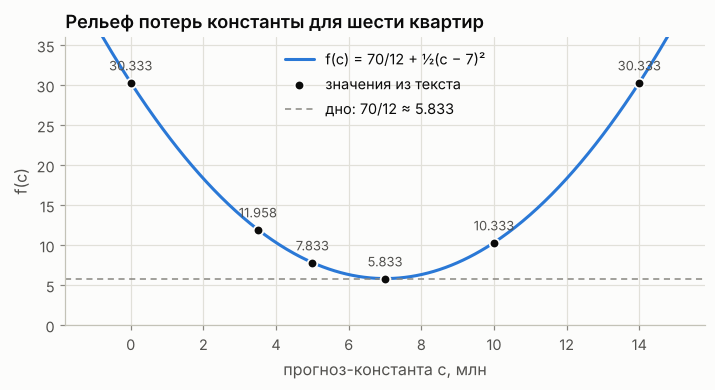

In [2]:
x = np.array([30, 40, 50, 60, 70, 80.0])  # площадь, м²
y = np.array([3, 5, 4, 8, 9, 13.0])  # цена, млн
f = lambda c: np.mean(0.5 * (y - c) ** 2)  # ½·MSE константы c — функция, дно которой ищем
f_short = lambda c: 70 / 12 + 0.5 * (c - 7) ** 2  # то же после разложения

dev2 = (y - y.mean()) ** 2
print(f"среднее ȳ = {y.mean():g}; сумма остатков от среднего = {np.sum(y - y.mean()):g} — перекрёстное слагаемое пропадает")
print(f"квадраты остатков от среднего: {' + '.join(f'{v:g}' for v in dev2)} = {dev2.sum():g}")
for c in (0, 3.5, 5, 7, 10, 14):
    print(f"f({c:>4}) = {f(c):7.3f}    70/12 + ½·({c} − 7)² = {f_short(c):7.3f}")
assert all(np.isclose(f(c), f_short(c)) for c in np.linspace(-5, 20, 101))

cs = np.linspace(-1, 15, 400)
pts = np.array([0, 3.5, 5, 7, 10, 14])
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(cs, [f(c) for c in cs], color=ROLE["model"], label="f(c) = 70/12 + ½(c − 7)²")
dot(ax, pts, [f(c) for c in pts], label="значения из текста")
for c in pts:
    ax.annotate(f"{f(c):.3f}", (c, f(c)), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8.5,
                color=style.INK_2)
ax.axhline(70 / 12, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="дно: 70/12 ≈ 5.833")
ax.set(xlabel="прогноз-константа c, млн", ylabel="f(c)", ylim=(0, 36),
       title="Рельеф потерь константы для шести квартир")
ax.legend()
plt.show()

**Три способа найти минимум.** Формула бывает редко. Перебор по сетке от 0 до 20 с шагом 0.01 — это 2001
вычисление на параметр, и с каждым новым параметром число точек умножается (**проклятие размерности**, curse of
dimensionality). Спуск идёт по склону, используя только наклон в текущей точке.

In [3]:
grid = np.round(np.arange(2001) * 0.01, 2)  # 0, 0.01, …, 20
values = np.array([f(c) for c in grid])
print(f"перебор: {grid.size} вычислений, лучшее c = {grid[values.argmin()]:g}, f = {values.min():.3f}")
for p, name in ((1, "один параметр"), (2, "два параметра"), (10, "десять параметров")):
    print(f"{name:18s}: {float(grid.size) ** p:.2e} точек сетки")
years = float(grid.size) ** 10 / 1e9 / (365.25 * 24 * 3600)
print(f"десять параметров при 10⁹ вычислений в секунду: {years:.1e} лет — "
      f"в {years / 13.8e9:.1e} раз дольше возраста Вселенной (13.8 млрд лет)")

перебор: 2001 вычислений, лучшее c = 7, f = 5.833
один параметр     : 2.00e+03 точек сетки
два параметра     : 4.00e+06 точек сетки
десять параметров : 1.03e+33 точек сетки
десять параметров при 10⁹ вычислений в секунду: 3.3e+16 лет — в 2.4e+06 раз дольше возраста Вселенной (13.8 млрд лет)


### Шаг 2. Что такое производная?

Производная — наклон функции в точке: предел наклона **секущей** (secant) через две точки графика, когда сдвиг
$\varepsilon$ стремится к нулю. Секущая при этом прижимается к **касательной** (tangent):

$$f'(\theta) = \lim_{\varepsilon \to 0} \frac{f(\theta + \varepsilon) - f(\theta)}{\varepsilon}.$$

Посчитаем наклон $f(c)$ квартир в точке $c = 0$, где $f(0) = 30.333$. Наклон секущей равен $-7 + \varepsilon/2$
и стремится к $f'(0) = -7$. Для $\theta^2$ в точке 3 он равен $6 + \varepsilon$ и стремится к 6.

In [4]:
print("Секущие f(c) в точке c = 0:")
print("     ε      f(ε)   наклон секущей   −7 + ε/2")
for eps in (1, 0.1, 0.01, 0.001):
    print(f"{eps:6g}  {f(eps):8.3f}   {(f(eps) - f(0)) / eps:12.4f}   {-7 + eps / 2:8.4f}")

sq = lambda t: t**2
print("θ² в точке 3:", ", ".join(f"ε = {e:g}: {(sq(3 + e) - sq(3)) / e:.2f}" for e in (1, 0.1, 0.01)), "→ f′(3) = 6")

Секущие f(c) в точке c = 0:
     ε      f(ε)   наклон секущей   −7 + ε/2
     1    23.833        -6.5000    -6.5000
   0.1    29.638        -6.9500    -6.9500
  0.01    30.263        -6.9950    -6.9950
 0.001    30.326        -6.9995    -6.9995
θ² в точке 3: ε = 1: 7.00, ε = 0.1: 6.10, ε = 0.01: 6.01 → f′(3) = 6


**Линейное приближение** (linear approximation) — определение без предела:
$f(\theta + \Delta) \approx f(\theta) + f'(\theta)\,\Delta$. Производная — «курс обмена» изменения аргумента на
изменение функции. Проверим на квартирах: при сдвиге $c$ с 0 на 0.1 функция должна уменьшиться примерно на
$7 \cdot 0.1 = 0.7$. Расхождение — «квадратичный довесок» $\tfrac12 f''\Delta^2$, к нему мы вернёмся в шаге 5.

In [5]:
d = 0.1
print(f"касательная обещает: f(0) + f′(0)·Δ = {f(0) - 7 * d:.3f}; на самом деле f(0.1) = {f(d):.3f}")
print(f"уменьшение: обещано {7 * d:.3f}, получено {f(0) - f(d):.3f}; "
      f"расхождение {f(d) - (f(0) - 7 * d):.3f} = ½·f″·Δ² = ½·1·{d}² = {0.5 * d**2:.3f}")

касательная обещает: f(0) + f′(0)·Δ = 29.633; на самом деле f(0.1) = 29.638
уменьшение: обещано 0.700, получено 0.695; расхождение 0.005 = ½·f″·Δ² = ½·1·0.1² = 0.005


**Глубже: численная производная.** Секущая «вперёд» ошибается примерно на $\tfrac12 f''\varepsilon$, а
**центральная разность** (central difference) $(f(\theta + \varepsilon) - f(\theta - \varepsilon))/2\varepsilon$ —
на величину порядка $\varepsilon^2$. Но и слишком маленькое $\varepsilon$ плохо: компьютер хранит около 16 значащих
цифр, и разность почти равных чисел теряет точность — **ошибка округления**. Для $f(\theta) = \theta^3$ в точке 1
($f' = 3$) ошибка сначала падает, потом растёт — на графике в логарифмических осях получается «галочка».

     ε    ошибка «вперёд»   ошибка центральной
  1e-01        3.1e-01            1.0e-02   ← таблица страницы
  1e-02        3.0e-02            1.0e-04
  1e-03        3.0e-03            1.0e-06
  1e-04        3.0e-04            1.0e-08   ← таблица страницы
  1e-05        3.0e-05            9.7e-11
  1e-06        3.0e-06            8.0e-11   ← таблица страницы
  1e-07        3.0e-07            8.6e-11
  1e-08        4.0e-09            7.1e-09   ← таблица страницы
  1e-09        2.5e-07            8.2e-08
  1e-10        2.5e-07            2.5e-07
  1e-11        2.5e-07            2.5e-07
  1e-12        2.7e-04            1.0e-04   ← таблица страницы
центральная (θ² в точке 3) точна при любом ε: 6
лучшее ε: «вперёд» 1e-08, центральная 1e-06


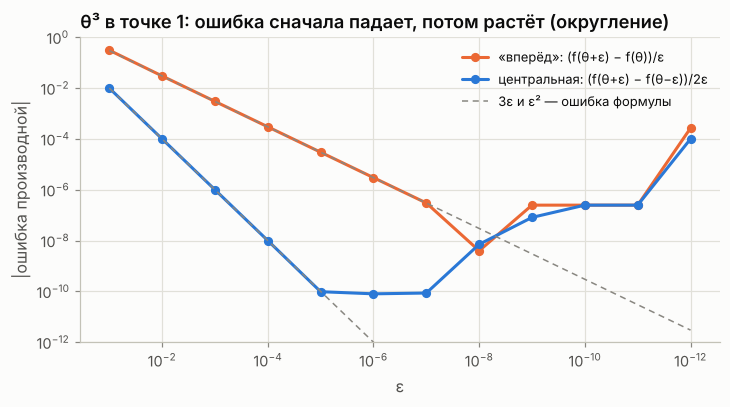

In [6]:
cube = lambda t: t**3
eps_list = [float(f"1e-{k}") for k in range(1, 13)]  # 10⁻¹ … 10⁻¹² (как литералы, без ошибок степени)
err_fwd = np.array([abs((cube(1 + e) - cube(1)) / e - 3) for e in eps_list])
err_cen = np.array([abs((cube(1 + e) - cube(1 - e)) / (2 * e) - 3) for e in eps_list])
print("     ε    ошибка «вперёд»   ошибка центральной")
for e, a, b in zip(eps_list, err_fwd, err_cen):
    mark = "   ← таблица страницы" if e in (1e-1, 1e-4, 1e-6, 1e-8, 1e-12) else ""
    print(f"{e:7.0e}   {a:12.1e}   {b:16.1e}{mark}")
print(f"центральная (θ² в точке 3) точна при любом ε: {((3 + 0.5) ** 2 - (3 - 0.5) ** 2) / (2 * 0.5):g}")
print(f"лучшее ε: «вперёд» {eps_list[err_fwd.argmin()]:g}, центральная {eps_list[err_cen.argmin()]:g}")

e_ref = np.array(eps_list)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.loglog(e_ref, err_fwd, marker="o", ms=5, color=ROLE["valid"], label="«вперёд»: (f(θ+ε) − f(θ))/ε")
ax.loglog(e_ref, err_cen, marker="o", ms=5, color=ROLE["train"], label="центральная: (f(θ+ε) − f(θ−ε))/2ε")
ax.loglog(e_ref, 3 * e_ref, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="3ε и ε² — ошибка формулы")
ax.loglog(e_ref, e_ref**2, color=style.MUTED, ls=(0, (4, 3)), lw=1)
ax.set(xlabel="ε", ylabel="|ошибка производной|", ylim=(1e-12, 1),
       title="θ³ в точке 1: ошибка сначала падает, потом растёт (округление)")
ax.invert_xaxis()
ax.legend(fontsize=8.5)
plt.show()
assert eps_list[err_cen.argmin()] in (1e-5, 1e-6) and err_cen[-1] > err_cen[4]

### Шаг 3. Как считать производные потерь?

Хватает нескольких правил: степень, множитель и сумма, **цепное правило** (chain rule)
$\big(g(u(\theta))\big)' = g'(u(\theta))\cdot u'(\theta)$, логарифм, экспонента, модуль. Проверим примеры из таблицы
страницы центральной разностью — так стоит проверять любую свою производную.

In [7]:
central = lambda fn, t, e=1e-6: (fn(t + e) - fn(t - e)) / (2 * e)  # численная производная (шаг 2)

rules = [
    ("степень: (θ²)′ = 2θ, θ = 3", lambda t: t**2, 3.0, 6.0),
    ("множитель и сумма: (½θ² + 3θ)′ = θ + 3, θ = 2", lambda t: 0.5 * t**2 + 3 * t, 2.0, 5.0),
    ("цепное: ((4 − c)²)′ = 2(4 − c)·(−1), c = 1", lambda c: (4 - c) ** 2, 1.0, -6.0),
    ("логарифм: (ln p)′ = 1/p, p = 0.25", np.log, 0.25, 4.0),
    ("экспонента: (e^{−F})′ = e^{−F}·(−1), F = 0", lambda F: np.exp(-F), 0.0, -1.0),
]
for name, fn, t, exact in rules:
    print(f"{name:48s} формула {exact:+.4f}, численно {central(fn, t):+.4f}")
    assert abs(central(fn, t) - exact) < 1e-6

степень: (θ²)′ = 2θ, θ = 3                       формула +6.0000, численно +6.0000
множитель и сумма: (½θ² + 3θ)′ = θ + 3, θ = 2    формула +5.0000, численно +5.0000
цепное: ((4 − c)²)′ = 2(4 − c)·(−1), c = 1       формула -6.0000, численно -6.0000
логарифм: (ln p)′ = 1/p, p = 0.25                формула +4.0000, численно +4.0000
экспонента: (e^{−F})′ = e^{−F}·(−1), F = 0       формула -1.0000, численно -1.0000


**Квадратичные потери.** $\partial_F \tfrac12 (y - F)^2 = -(y - F)$: антиградиент — **остаток**. Для константы
квартир производная суммы — сумма производных: $f'(c) = \frac16\sum -(y_i - c) = c - \bar y = c - 7$.

In [8]:
df = lambda c: c - y.mean()  # f′(c) для ½·MSE константы

terms = -(y - 5)
print("остатки yᵢ − 5:", y - 5, "\nпроизводные слагаемых −(yᵢ − 5):", terms,
      f"\nих сумма {terms.sum():g}, среднее {terms.mean():g} = 5 − 7")
for c in (0, 3, 7, 10):
    print(f"f′({c:>2}) = {df(c):+g}   численно {central(f, c):+.4f}")
assert np.isclose(terms.mean(), -2) and all(np.isclose(df(c), central(f, c)) for c in (0, 3, 7, 10))

остатки yᵢ − 5: [-2.  0. -1.  3.  4.  8.] 
производные слагаемых −(yᵢ − 5): [ 2. -0.  1. -3. -4. -8.] 
их сумма -12, среднее -2 = 5 − 7
f′( 0) = -7   численно -7.0000
f′( 3) = -4   численно -4.0000
f′( 7) = +0   численно +0.0000
f′(10) = +3   численно +3.0000


**Абсолютные потери.** $\partial_F |y - F| = -\operatorname{sign}(y - F)$: антиградиент — **знак остатка**.
Для константы $f(c) = \tfrac16\sum|y_i - c|$ при $c$, не равном ни одной из цен,
$f'(c) = \big((\text{цен ниже } c) - (\text{цен выше } c)\big)/6$. Между 5 и 8 три цены ниже и три выше —
минимум не точка, а **отрезок** $[5, 8]$ (множество медиан из урока 1.2). В самих ценах производной нет:
годится любой наклон между левым и правым — **субградиент** (subgradient); `np.sign(0) = 0` — один из вариантов.

In [9]:
f_mae = lambda c: np.mean(np.abs(y - c))
df_mae = lambda c: (np.sum(y < c) - np.sum(y > c)) / 6
for c in (0, 4.5, 10, 5.5, 6.5, 7.9):
    print(f"c = {c:>4}: ниже {np.sum(y < c)}, выше {np.sum(y > c)} → f′(c) = {df_mae(c):+.4f}, "
          f"численно {central(f_mae, c):+.4f}, f(c) = {f_mae(c):.4f}")
assert np.isclose(df_mae(4.5), -1 / 3) and np.isclose(df_mae(10), 2 / 3)

c =    0: ниже 0, выше 6 → f′(c) = -1.0000, численно -1.0000, f(c) = 7.0000
c =  4.5: ниже 2, выше 4 → f′(c) = -0.3333, численно -0.3333, f(c) = 3.1667
c =   10: ниже 5, выше 1 → f′(c) = +0.6667, численно +0.6667, f(c) = 4.0000
c =  5.5: ниже 3, выше 3 → f′(c) = +0.0000, численно +0.0000, f(c) = 3.0000
c =  6.5: ниже 3, выше 3 → f′(c) = +0.0000, численно +0.0000, f(c) = 3.0000
c =  7.9: ниже 3, выше 3 → f′(c) = +0.0000, численно +0.0000, f(c) = 3.0000


**Log-loss.** Модель выдаёт логит $F$, вероятность $p = \sigma(F) = 1/(1 + e^{-F})$, потери
$L = -\big[y\ln p + (1 - y)\ln(1 - p)\big]$. Цепочка $F \to p \to L$: $\sigma'(F) = p(1 - p)$,
$\partial L/\partial p = (p - y)/\big(p(1 - p)\big)$, и после умножения $p(1 - p)$ сокращается:
$\partial L/\partial F = p - y$.

In [10]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))
logloss_1 = lambda F, yy: -(yy * np.log(sigmoid(F)) + (1 - yy) * np.log(1 - sigmoid(F)))

for F in (-1.0, 0.0, 0.3):
    p = sigmoid(F)
    print(f"F = {F:+.1f}: σ′ = p(1 − p) = {p * (1 - p):.6f}, численно {central(sigmoid, F):.6f}")
print("\nСлучай            F  y      p   ∂L/∂F = p − y   численно   p(1 − p)")
for case, F, yy in (("не уверен", 0, 1), ("уверен и прав", 2, 1), ("уверен и ошибся", 2, 0)):
    p = sigmoid(F)
    num = central(lambda t, yy=yy: logloss_1(t, yy), F)
    print(f"{case:15s} {F:3d} {yy:2d}  {p:5.3f}   {p - yy:+13.3f}   {num:+8.3f}   {p * (1 - p):8.3f}")
    assert abs(num - (p - yy)) < 1e-6

print("\nПсевдо-остатки −∂L/∂F (то, чему учится дерево):")
print(f"  ½·MSE: квартира за 13 млн при F = 7 → остаток {13 - 7:+d}")
print(f"  MAE:   та же квартира → знак остатка {np.sign(13 - 7):+.0f}")
print(f"  log-loss: y = 1, F = 0 (p = 0.5) → y − p = {1 - sigmoid(0):+.1f}")

F = -1.0: σ′ = p(1 − p) = 0.196612, численно 0.196612
F = +0.0: σ′ = p(1 − p) = 0.250000, численно 0.250000
F = +0.3: σ′ = p(1 − p) = 0.244458, численно 0.244458

Случай            F  y      p   ∂L/∂F = p − y   численно   p(1 − p)
не уверен         0  1  0.500          -0.500     -0.500      0.250
уверен и прав     2  1  0.881          -0.119     -0.119      0.105
уверен и ошибся   2  0  0.881          +0.881     +0.881      0.105

Псевдо-остатки −∂L/∂F (то, чему учится дерево):
  ½·MSE: квартира за 13 млн при F = 7 → остаток +6
  MAE:   та же квартира → знак остатка +1
  log-loss: y = 1, F = 0 (p = 0.5) → y − p = +0.5


**Вторая производная — кривизна.** $f''$ показывает, как быстро меняется сам наклон. У квартир $f'(c) = c - 7$,
значит $f'' = 1$; у MAE $f'' = 0$ между изломами; у log-loss $f'' = p(1 - p) \le 0.25$ — кривизна меняется.
На графиках ниже — производные трёх потерь: это «силы», с которыми объекты тянут прогноз.

½·MSE квартир: f″(2) = 1.0000, f″(9) = 1.0000
MAE квартир:   f″(6.5) = 0.0000 (между изломами)
log-loss, F = +0: ∂²L/∂F² = 0.2500, p(1 − p) = 0.2500
log-loss, F = +2: ∂²L/∂F² = 0.1050, p(1 − p) = 0.1050
log-loss, F = -3: ∂²L/∂F² = 0.0452, p(1 − p) = 0.0452


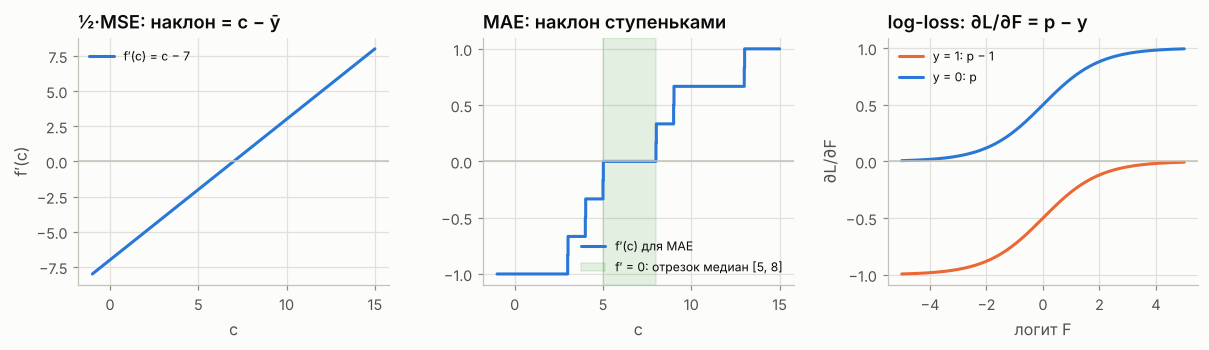

In [11]:
second = lambda fn, t, e=1e-4: (fn(t + e) - 2 * fn(t) + fn(t - e)) / e**2
print(f"½·MSE квартир: f″(2) = {second(f, 2.0):.4f}, f″(9) = {second(f, 9.0):.4f}")
print(f"MAE квартир:   f″(6.5) = {second(f_mae, 6.5):.4f} (между изломами)")
for F in (0.0, 2.0, -3.0):
    print(f"log-loss, F = {F:+.0f}: ∂²L/∂F² = {second(lambda t: logloss_1(t, 1), F):.4f}, "
          f"p(1 − p) = {sigmoid(F) * (1 - sigmoid(F)):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
cs = np.linspace(-1, 15, 801)
axes[0].plot(cs, df(cs), color=ROLE["model"], label="f′(c) = c − 7")
axes[0].set(title="½·MSE: наклон = c − ȳ", xlabel="c", ylabel="f′(c)")
axes[1].plot(cs, [df_mae(c) for c in cs], color=ROLE["model"], drawstyle="steps-post", label="f′(c) для MAE")
axes[1].axvspan(5, 8, color=style.GREEN, alpha=0.1, label="f′ = 0: отрезок медиан [5, 8]")
axes[1].set(title="MAE: наклон ступеньками", xlabel="c")
Fs = np.linspace(-5, 5, 401)
axes[2].plot(Fs, sigmoid(Fs) - 1, color=ROLE["classes"][1], label="y = 1: p − 1")
axes[2].plot(Fs, sigmoid(Fs), color=ROLE["classes"][0], label="y = 0: p")
axes[2].set(title="log-loss: ∂L/∂F = p − y", xlabel="логит F", ylabel="∂L/∂F")
for ax in axes:
    ax.axhline(0, color=style.AXIS, lw=1)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

> **Привал I: что мы уже умеем.**
> - Обучение — поиск дна функции потерь; формула бывает редко, перебор невозможен, поэтому спускаются по склону.
> - Наклон в точке — производная; $f(\theta + \Delta) \approx f(\theta) + f'(\theta)\Delta$.
> - Производные потерь: $-(y - F)$, $-\operatorname{sign}(y - F)$, $p - y$; минус производная — псевдо-остаток.

## Часть II. Как шагать: спуск по одной переменной

Собираем алгоритм, доказываем, что он работает, и разбираемся с главным вопросом практики — длиной шага. В конце —
шаг Ньютона, из которого вырастает XGBoost.

### Шаг 4. Как устроен градиентный спуск?

Посмотреть на наклон, сдвинуться против него на долю $\eta$ (**темп обучения**, learning rate) и повторить —
пока склон не станет почти горизонтальным: $\theta_{k+1} = \theta_k - \eta\, f'(\theta_k)$. Весь алгоритм — одна
функция (та же, что в разделе «В коде» страницы).

In [12]:
def gradient_descent(df, theta0, eta, tol=1e-6, max_steps=1000):
    """Спуск θ ← θ − η·f′(θ), пока |f′| не станет меньше tol. Возвращает путь."""
    path = [theta0]
    theta = theta0
    for _ in range(max_steps):
        g = df(theta)  # 1. наклон под ногами
        if np.all(np.abs(g) < tol):  # 2. склон плоский — пришли
            break
        theta = theta - eta * g  # 3. шаг против наклона
        path.append(theta)
    return path


print("Спуск руками: квартиры, ½·MSE, c₀ = 0, η = 0.5")
print(" k      c_k     f(c_k)   f′(c_k)   c_{k+1}   длина шага   до минимума")
path = gradient_descent(df, 0.0, eta=0.5, max_steps=5)
for k, c in enumerate(path[:5]):
    c_next = c - 0.5 * df(c)
    print(f"{k:2d} {c:8.4f} {f(c):10.3f} {df(c):9.4f} {c_next:9.4f} {abs(c_next - c):12.4f} {abs(7 - c):12.4f}")

# тот же шаг — «бустинг одного числа» из урока 1: прибавить долю η среднего остатка
c_boost = 0.0
for _ in range(5):
    c_boost = c_boost + 0.5 * np.mean(y - c_boost)
assert np.isclose(c_boost, path[-1])
print(f"«бустинг одного числа» с ν = 0.5 после 5 шагов: {c_boost:.5f} — то же, что спуск: {path[-1]:.5f}")

Спуск руками: квартиры, ½·MSE, c₀ = 0, η = 0.5
 k      c_k     f(c_k)   f′(c_k)   c_{k+1}   длина шага   до минимума
 0   0.0000     30.333   -7.0000    3.5000       3.5000       7.0000
 1   3.5000     11.958   -3.5000    5.2500       1.7500       3.5000
 2   5.2500      7.365   -1.7500    6.1250       0.8750       1.7500
 3   6.1250      6.216   -0.8750    6.5625       0.4375       0.8750
 4   6.5625      5.929   -0.4375    6.7812       0.2188       0.4375
«бустинг одного числа» с ν = 0.5 после 5 шагов: 6.78125 — то же, что спуск: 6.78125


**Спуск как перетягивание каната.** Каждая квартира тянет прогноз к себе с силой $-\partial L(y_i, c)/\partial c$ —
своим псевдо-остатком. Спуск складывает силы, усредняет и сдвигает $c$ на долю $\eta$ средней силы. Для ½·MSE сила —
остаток (квартира за 13 млн при $c = 7$ тянет в 6 раз сильнее квартиры за 8 млн); для MAE — ±1. Спуск по MAE
с $\eta = 0.5$ из нуля: шесть шагов по 0.5, затем 0.417, 0.333, 0.333 и шесть по 0.167 — на 15-м шаге
$c = 5.083$ внутри отрезка $[5, 8]$, силы уравновешены, спуск стоит.

силы при c = 7: ½·MSE [-4. -2. -3.  1.  2.  6.] | MAE [-1. -1. -1.  1.  1.  1.]
½·MSE : c₁₅ = 6.9998, c₂₀ = 7.0000, средняя сила в конце +0.0000
MAE   : c₁₅ = 5.0833, c₂₀ = 5.0833, средняя сила в конце +0.0000
длины шагов MAE: [0.5   0.5   0.5   0.5   0.5   0.5   0.417 0.333 0.333 0.167 0.167 0.167
 0.167 0.167 0.167]


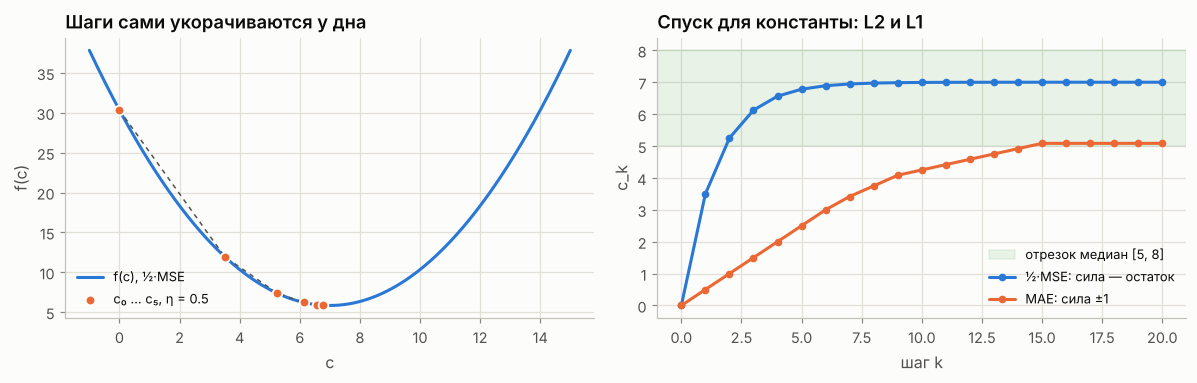

In [13]:
print("силы при c = 7: ½·MSE", y - 7, "| MAE", np.sign(y - 7))
paths = {}
for name, pull in (("½·MSE", lambda c: y - c), ("MAE", lambda c: np.sign(y - c))):
    c, cpath = 0.0, [0.0]
    for _ in range(20):
        c = c + 0.5 * pull(c).mean()  # шаг на долю средней силы = −f′(c)
        cpath.append(c)
    paths[name] = np.array(cpath)
    print(f"{name:6s}: c₁₅ = {cpath[15]:.4f}, c₂₀ = {cpath[20]:.4f}, средняя сила в конце {pull(c).mean():+.4f}")
print("длины шагов MAE:", np.round(np.diff(paths["MAE"][:16]), 3))
assert np.isclose(paths["MAE"][15], 5.0833, atol=1e-4) and np.isclose(paths["MAE"][16], paths["MAE"][15])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
cs = np.linspace(-1, 15, 300)
axes[0].plot(cs, [f(c) for c in cs], color=ROLE["model"], label="f(c), ½·MSE")
p5 = np.array(path)
axes[0].plot(p5, [f(c) for c in p5], color=style.INK_2, lw=1, ls=(0, (3, 3)))
dot(axes[0], p5, [f(c) for c in p5], color=ROLE["tree"], label="c₀ … c₅, η = 0.5")
axes[0].set(xlabel="c", ylabel="f(c)", title="Шаги сами укорачиваются у дна")
axes[1].axhspan(5, 8, color=style.GREEN, alpha=0.08, label="отрезок медиан [5, 8]")
axes[1].plot(paths["½·MSE"], marker="o", ms=4, color=ROLE["train"], label="½·MSE: сила — остаток")
axes[1].plot(paths["MAE"], marker="o", ms=4, color=ROLE["valid"], label="MAE: сила ±1")
axes[1].set(xlabel="шаг k", ylabel="c_k", title="Спуск для константы: L2 и L1")
for ax in axes:
    ax.legend(fontsize=8.5)
fig.tight_layout()
plt.show()

### Шаг 5. Почему шаг против производной уменьшает функцию?

Подставим шаг $\Delta = -\eta f'$ в линейное приближение: $f(\theta - \eta f') \approx f(\theta) - \eta f'^2$.
Квадрат не бывает отрицательным — при маленьком $\eta > 0$ функция уменьшается. Но касательная не знает, что
функция загибается вверх. Для параболы с кривизной $a = f''$ ошибку обещания можно посчитать точно:

$$f(\theta - \eta f') = f(\theta) - \eta\Big(1 - \frac{a\eta}{2}\Big) f'^2 .$$

Скобка $1 - a\eta/2$ — «доля обещания»: выигрыш положителен при $0 < \eta < 2/a$ и максимален при $\eta = 1/a$
(тогда он ровно вдвое меньше обещанного). Проверим на квартирах в точке $c = 0$: $f'^2 = 49$, $a = 1$.

In [14]:
g0 = df(0.0)  # −7
print(" η      c₁   обещание касательной   на самом деле f(c₁)   доля обещания   1 − η/2")
for eta in (0.1, 0.5, 1, 2, 2.5):
    c1 = 0.0 - eta * g0
    promise, actual = f(0) - eta * g0**2, f(c1)
    share = (f(0) - actual) / (eta * g0**2)
    print(f"{eta:4g} {c1:6.1f} {promise:18.3f} {actual:20.3f} {share:13.0%} {1 - eta / 2:9.2f}")
    assert np.isclose(actual, f(0) - eta * (1 - eta / 2) * g0**2)
print(f"η = 0.5: выигрыш {f(0) - f(3.5):.1f} из обещанных {0.5 * 49:.1f}")

 η      c₁   обещание касательной   на самом деле f(c₁)   доля обещания   1 − η/2
 0.1    0.7             25.433               25.678           95%      0.95
 0.5    3.5              5.833               11.958           75%      0.75
   1    7.0            -18.667                5.833           50%      0.50
   2   14.0            -67.667               30.333            0%      0.00
 2.5   17.5            -92.167               60.958          -25%     -0.25
η = 0.5: выигрыш 18.4 из обещанных 24.5


**Гарантия для любой функции — лемма о спуске** (descent lemma). Если кривизна ограничена сверху, $f'' \le L$
всюду, то $f(\theta - \eta f') \le f(\theta) - \eta(1 - L\eta/2) f'^2$: при $0 < \eta < 2/L$ функция уменьшается
из любой точки. Для log-loss $L = 0.25$, гарантия — $\eta < 8$. Возьмём log-loss константы для 10 клиентов, трое
из которых не вернули кредит ($y = 1$; к ним вернёмся в шаге 9): из $F = 0$ функция фактически уменьшается вплоть до
$\eta \approx 9.0$, лучший темп ≈ 4.24 — оценка осторожна, но верна. У $\theta^4/4$ из точки 1.5 касательная
«врёт» уже при небольших шагах — кривизна там велика.

log-loss из F = 0: f′ = 0.2; функция уменьшается при η < 9.01, лучший η ≈ 4.24
  1/f″ в старте = 4.00, у дна = 4.76; лемма гарантирует η < 2/0.25 = 8
наибольшее превышение оценки леммы на сетке θ ∈ [−4, 4], η ∈ [0.1, 12]: -8.33e-10 (≤ 0 — лемма верна)
θ⁴/4 из 1.5, η = 0.1: доля обещания +71%
θ⁴/4 из 1.5, η = 0.2: доля обещания +50%
θ⁴/4 из 1.5, η = 0.3: доля обещания +37%
θ⁴/4 из 1.5, η = 0.6: доля обещания +18%


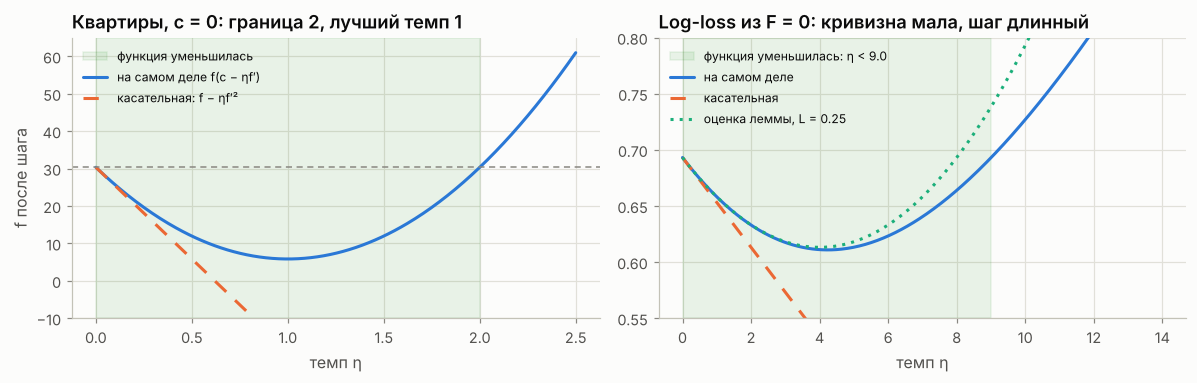

In [15]:
yk = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0])  # 10 клиентов, 3 должника
ll = lambda F: np.mean(np.log1p(np.exp(F)) - yk * F)  # средний log-loss константы-логита F
dll = lambda F: sigmoid(F) - yk.mean()  # f′(F) = p − 0.3
d2ll = lambda F: sigmoid(F) * (1 - sigmoid(F))  # f″(F) = p(1 − p) ≤ 0.25

etas = np.linspace(0, 14, 14001)
after = np.array([ll(0 - e * dll(0)) for e in etas])
edge = etas[after < ll(0) - 1e-12].max()
best = etas[after.argmin()]
print(f"log-loss из F = 0: f′ = {dll(0):.1f}; функция уменьшается при η < {edge:.2f}, лучший η ≈ {best:.2f}")
print(f"  1/f″ в старте = {1 / d2ll(0):.2f}, у дна = {1 / d2ll(np.log(0.3 / 0.7)):.2f}; лемма гарантирует η < 2/0.25 = 8")

# проверим саму лемму: оценка сверху выполняется в любой точке при любом η
Lmax = 0.25
worst = max(ll(t - e * dll(t)) - (ll(t) - e * (1 - Lmax * e / 2) * dll(t) ** 2)
            for t in np.linspace(-4, 4, 41) for e in np.linspace(0.1, 12, 60))
print(f"наибольшее превышение оценки леммы на сетке θ ∈ [−4, 4], η ∈ [0.1, 12]: {worst:.2e} (≤ 0 — лемма верна)")
assert 8.95 < edge < 9.05 and abs(best - 4.24) < 0.01 and worst <= 1e-12

q4, dq4 = lambda t: t**4 / 4, lambda t: t**3
for eta in (0.1, 0.2, 0.3, 0.6):
    gain, promise = q4(1.5) - q4(1.5 - eta * dq4(1.5)), eta * dq4(1.5) ** 2
    print(f"θ⁴/4 из 1.5, η = {eta}: доля обещания {gain / promise:+.0%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
e1 = np.linspace(0, 2.5, 300)
axes[0].axvspan(0, 2, color=style.GREEN, alpha=0.08, label="функция уменьшилась")
axes[0].plot(e1, [f(-e * g0) for e in e1], color=ROLE["model"], label="на самом деле f(c − ηf′)")
axes[0].plot(e1, f(0) - e1 * g0**2, color=ROLE["tree"], ls=(0, (5, 4)), label="касательная: f − ηf′²")
axes[0].axhline(f(0), color=style.MUTED, ls=(0, (4, 3)), lw=1)
axes[0].set(xlabel="темп η", ylabel="f после шага", ylim=(-10, 65), title="Квартиры, c = 0: граница 2, лучший темп 1")
e2 = np.linspace(0, 14, 400)
axes[1].axvspan(0, edge, color=style.GREEN, alpha=0.08, label=f"функция уменьшилась: η < {edge:.1f}")
axes[1].plot(e2, [ll(-e * dll(0)) for e in e2], color=ROLE["model"], label="на самом деле")
axes[1].plot(e2, ll(0) - e2 * dll(0) ** 2, color=ROLE["tree"], ls=(0, (5, 4)), label="касательная")
axes[1].plot(e2, ll(0) - e2 * (1 - Lmax * e2 / 2) * dll(0) ** 2, color=ROLE["test"], ls=(0, (1, 2)),
             label="оценка леммы, L = 0.25")
axes[1].set(xlabel="темп η", ylim=(0.55, 0.8), title="Log-loss из F = 0: кривизна мала, шаг длинный")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Шаг 6. Какой взять темп?

Для параболы $\tfrac a2\theta^2$ шаг спуска — умножение: $\theta_{k+1} = (1 - \eta a)\,\theta_k$. Всё решает
множитель $1 - \eta a$. У квартир $a = 1$, и каждый шаг умножает расстояние до среднего на $1 - \eta$:
$c_k = 7 - 7(1 - \eta)^k$. Скорость зависит только от $|1 - \eta a|$: $\eta = 0.5$ и $\eta = 1.5$ сходятся одинаково
быстро, только с разных сторон.

In [16]:
def steps_to_1pct(q):
    """Шагов до 1 % исходного расстояния при множителе q (None — не сходится)."""
    if abs(q) < 1e-12:
        return 1
    if abs(q) >= 1:
        return None
    return int(np.ceil(np.log(0.01) / np.log(abs(q)) - 1e-12))


regimes = {0.5: "осторожно, с одной стороны", 1: "идеально: сразу в минимум", 1.5: "перелёт, но сходится",
           1.9: "сильные качели", 2: "вечные качели 0 ↔ 14", 2.1: "разнос"}
print(" η   множитель     c₁      c₂      c₃   шагов до 1 %   режим")
for eta, mode in regimes.items():
    q = 1 - eta
    c123 = [7 - 7 * q**k for k in (1, 2, 3)]
    n = steps_to_1pct(q)
    print(f"{eta:3g} {q:+9.1f} {c123[0]:7.3f} {c123[1]:7.3f} {c123[2]:7.3f} {n if n else 'никогда':>12}   {mode}")
print(f"слишком маленький темп: η = 0.05 → {steps_to_1pct(0.95)} шагов, η = 0.01 → {steps_to_1pct(0.99)}")
assert [steps_to_1pct(1 - e) for e in (0.5, 1, 1.5, 1.9)] == [7, 1, 7, 44]

 η   множитель     c₁      c₂      c₃   шагов до 1 %   режим
0.5      +0.5   3.500   5.250   6.125            7   осторожно, с одной стороны
  1      +0.0   7.000   7.000   7.000            1   идеально: сразу в минимум
1.5      -0.5  10.500   5.250   7.875            7   перелёт, но сходится
1.9      -0.9  13.300   1.330  12.103           44   сильные качели
  2      -1.0  14.000   0.000  14.000      никогда   вечные качели 0 ↔ 14
2.1      -1.1  14.700  -1.470  16.317      никогда   разнос
слишком маленький темп: η = 0.05 → 90 шагов, η = 0.01 → 459


**Скорость: линейная сходимость.** После $k$ шагов остаётся доля $q^k$, $q = |1 - \eta a|$; чтобы уменьшить
расстояние в $1/\epsilon$ раз, нужно $k = \ln\epsilon/\ln q \approx \ln(1/\epsilon)/(\eta a)$ шагов. При $q = 0.5$
до 1 % нужно $\ln 0.01/\ln 0.5 = 6.6 \to 7$ шагов, и каждый шаг добавляет 0.3 верного знака. На графике ошибки в
логарифмической шкале это прямая линия.

**В бустинге:** в «бустинге одного числа» остаток после $M$ шагов умножается на $(1 - \nu)^M \approx e^{-\nu M}$ —
прогресс определяет произведение $\nu M$.

q = 0.5: ln 0.01 / ln 0.5 = 6.6 → 7 шагов; верных знаков за шаг: 0.30
 ν      M до 1 %   ν·M    4.6/ν
0.5           7   3.50        9
0.3          13   3.90       15
0.1          44   4.40       46
0.01        459   4.59      460


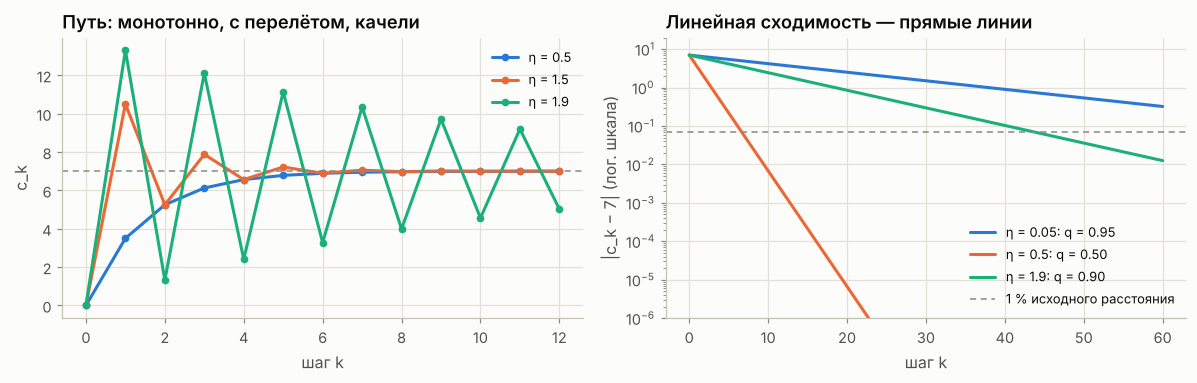

In [17]:
print(f"q = 0.5: ln 0.01 / ln 0.5 = {np.log(0.01) / np.log(0.5):.1f} → 7 шагов; верных знаков за шаг: {np.log10(2):.2f}")
print(" ν      M до 1 %   ν·M    4.6/ν")
for nu in (0.5, 0.3, 0.1, 0.01):
    M = steps_to_1pct(1 - nu)
    print(f"{nu:<5g} {M:9d} {nu * M:6.2f} {4.6 / nu:8.0f}")
assert [steps_to_1pct(1 - nu) for nu in (0.5, 0.3, 0.1, 0.01)] == [7, 13, 44, 459]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ks = np.arange(13)
for eta, color in zip((0.5, 1.5, 1.9), style.SERIES):
    axes[0].plot(ks, 7 - 7 * (1 - eta) ** ks, marker="o", ms=4, color=color, label=f"η = {eta}")
axes[0].axhline(7, color=style.MUTED, ls=(0, (4, 3)), lw=1)
axes[0].set(xlabel="шаг k", ylabel="c_k", title="Путь: монотонно, с перелётом, качели")
ks = np.arange(61)
for eta, color in zip((0.05, 0.5, 1.9), style.SERIES):
    axes[1].semilogy(ks, 7 * np.abs(1 - eta) ** ks, color=color, label=f"η = {eta}: q = {abs(1 - eta):.2f}")
axes[1].axhline(0.07, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="1 % исходного расстояния")
axes[1].set(xlabel="шаг k", ylabel="|c_k − 7| (лог. шкала)", ylim=(1e-6, 20), title="Линейная сходимость — прямые линии")
for ax in axes:
    ax.legend(fontsize=8.5)
fig.tight_layout()
plt.show()

### Шаг 7. Где спуск буксует?

Три неудобных случая:
- **плоское дно** $\theta^4/4$: производная $\theta^3$ у дна почти нулевая, кривизна в минимуме $f'' = 0$;
- **излом** $|\theta|$: производная везде ±1, точка «дребезжит» вокруг нуля с размахом $\eta$;
- **две ямы** $\theta^4/4 - \theta^2 + 0.3\theta$: спуск находит ту яму, на склоне которой стартовал, —
  **локальный минимум** (local minimum), а не обязательно **глобальный**.

θ⁴/4 из 0.1, η = 0.5: шаг сдвигает точку на 0.0005
  из θ = 1 за    10 шагов: θ = 0.2672
  из θ = 1 за   100 шагов: θ = 0.0973
  из θ = 1 за  1000 шагов: θ = 0.0315
  из θ = 1 за 10000 шагов: θ = 0.0100
  приблизиться в 10 раз стоит в 100 раз больше шагов: θ_k ≈ 1/√k
плоское дно, старт 2.5, η = 0.2: первый шаг → -0.625; кривизна там 18.75, граница 2/a = 0.107
излом |θ|, η = 0.3, старт 2.05, последние шаги: [-0.05  0.25 -0.05  0.25 -0.05  0.25]
две ямы: θ = -1.48, f = -1.435, f″ = +4.6 → минимум
две ямы: θ = +0.15, f = +0.023, f″ = -1.9 → горб (максимум)
две ямы: θ = +1.33, f = -0.588, f″ = +3.3 → минимум
  старт +0.16 → θ = +1.3322, f = -0.5877
  старт +0.14 → θ = -1.4840, f = -1.4350
  старт +0.50 → θ = +1.3322, f = -0.5877
  старт -0.50 → θ = -1.4840, f = -1.4350


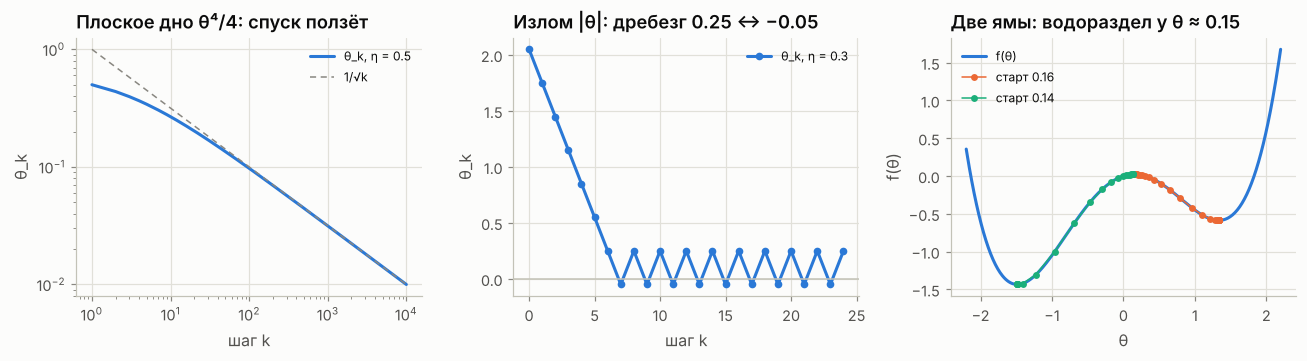

In [18]:
t = 0.1
print(f"θ⁴/4 из 0.1, η = 0.5: шаг сдвигает точку на {0.5 * t**3:.4f}")
t, flat_path = 1.0, [1.0]
for _ in range(10000):
    t -= 0.5 * t**3
    flat_path.append(t)
for k in (10, 100, 1000, 10000):
    print(f"  из θ = 1 за {k:>5} шагов: θ = {flat_path[k]:.4f}")
print("  приблизиться в 10 раз стоит в 100 раз больше шагов: θ_k ≈ 1/√k")
t = 2.5
print(f"плоское дно, старт 2.5, η = 0.2: первый шаг → {t - 0.2 * t**3:.3f}; кривизна там {3 * t**2:.2f}, "
      f"граница 2/a = {2 / (3 * t**2):.3f}")
assert abs(flat_path[1000] - 0.0315) < 5e-5

t, kink = 2.05, []
for _ in range(60):
    t -= 0.3 * np.sign(t)
    kink.append(t)
print("излом |θ|, η = 0.3, старт 2.05, последние шаги:", np.round(kink[-6:], 2))

pits = lambda t: t**4 / 4 - t**2 + 0.3 * t
dpits = lambda t: t**3 - 2 * t + 0.3
d2pits = lambda t: 3 * t**2 - 2
for r in np.sort(np.roots([1, 0, -2, 0.3]).real):  # f′ = θ³ − 2θ + 0.3 = 0
    kind = "минимум" if d2pits(r) > 0 else "горб (максимум)"
    print(f"две ямы: θ = {r:+.2f}, f = {pits(r):+.3f}, f″ = {d2pits(r):+.1f} → {kind}")
pit_paths = {}
for t0 in (0.16, 0.14, 0.5, -0.5):
    pit_paths[t0] = gradient_descent(dpits, t0, eta=0.2)
    t = pit_paths[t0][-1]
    print(f"  старт {t0:+.2f} → θ = {t:+.4f}, f = {pits(t):+.4f}")
assert pit_paths[0.16][-1] > 1 and pit_paths[0.14][-1] < -1

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].loglog(np.arange(1, 10001), flat_path[1:], color=ROLE["model"], label="θ_k, η = 0.5")
axes[0].loglog(np.arange(1, 10001), 1 / np.sqrt(np.arange(1, 10001)), color=style.MUTED, ls=(0, (4, 3)), lw=1,
               label="1/√k")
axes[0].set(xlabel="шаг k", ylabel="θ_k", title="Плоское дно θ⁴/4: спуск ползёт")
axes[1].plot(np.r_[2.05, kink[:24]], marker="o", ms=4, color=ROLE["model"], label="θ_k, η = 0.3")
axes[1].axhline(0, color=style.AXIS, lw=1)
axes[1].set(xlabel="шаг k", ylabel="θ_k", title="Излом |θ|: дребезг 0.25 ↔ −0.05")
ts = np.linspace(-2.2, 2.2, 400)
axes[2].plot(ts, pits(ts), color=ROLE["model"], label="f(θ)")
for t0, color in ((0.16, ROLE["tree"]), (0.14, ROLE["test"])):
    pp = np.array(pit_paths[t0][:40])
    axes[2].plot(pp, pits(pp), marker="o", ms=3.5, color=color, lw=1, label=f"старт {t0}")
axes[2].set(xlabel="θ", ylabel="f(θ)", title="Две ямы: водораздел у θ ≈ 0.15")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Минимум или максимум?** Точка с $f'(\theta^*) = 0$ — только кандидат: $f'' > 0$ — минимум, $f'' < 0$ —
максимум, $f'' = 0$ — нужно смотреть дальше ($\theta^3$ в нуле — «полочка», $\theta^4/4$ — минимум).

**Выпуклость спасает от ложных ям.** **Выпуклая функция** (convex) — «чаша без кочек»: отрезок между любыми двумя
точками графика лежит не ниже графика. У неё любой найденный спуском минимум — глобальный. Проверим определение
на случайных парах точек: все потери урока 1.2 выпуклы по прогнозу, а «две ямы» — нет.

In [19]:
rng_check = Mulberry32(7)
pairs = [(rng_check.uniform(-3, 15), rng_check.uniform(-3, 15), rng_check.random()) for _ in range(2000)]
for name, fn in (("½·MSE квартир", f), ("MAE квартир", f_mae), ("log-loss клиентов", ll), ("две ямы", pits)):
    # выпуклость: f(λa + (1 − λ)b) ≤ λ f(a) + (1 − λ) f(b)
    bad = sum(fn(lam * a + (1 - lam) * b) > lam * fn(a) + (1 - lam) * fn(b) + 1e-12 for a, b, lam in pairs)
    print(f"{name:18s}: нарушений выпуклости {bad} из {len(pairs)} → {'выпукла' if bad == 0 else 'не выпукла'}")

½·MSE квартир     : нарушений выпуклости 0 из 2000 → выпукла
MAE квартир       : нарушений выпуклости 0 из 2000 → выпукла
log-loss клиентов : нарушений выпуклости 0 из 2000 → выпукла
две ямы           : нарушений выпуклости 62 из 2000 → не выпукла


### Шаг 8. Как подобрать темп и когда остановиться?

Формула $\eta^* = 1/a$ требует знать кривизну, а на практике её не знают. Три приёма.

**1. Сетка по степеням десяти.** Log-loss константы с 30 % единиц, 10 шагов из $F = 0$; минимум
$f = 0.61086$ в $F^* = -0.847$. Темп — логарифмический параметр.

In [20]:
F_star = np.log(0.3 / 0.7)
print(f"минимум: F* = {F_star:.3f}, f = {ll(F_star):.5f}")


def ll_descent(eta, K=10, F=0.0):
    """K шагов спуска по log-loss константы; возвращает путь F₁ … F_K."""
    out = []
    for _ in range(K):
        F = F - eta * dll(F)
        out.append(F)
    return out


print("   η   F после 10 шагов        f   первые шаги")
for eta in (100, 10, 1, 0.1):
    p10 = ll_descent(eta)
    print(f"{eta:5g} {p10[-1]:12.3f} {ll(p10[-1]):12.5f}   {np.round(p10[:4], 2)}")
print("уточняем множителями около 1: ошибка |F − F*| после 10 шагов")
for eta in (2, 3, 5, 8):
    print(f"  η = {eta}: {abs(ll_descent(eta)[-1] - F_star):.1e}")
print(f"у дна 1/f″ = 1/{d2ll(F_star):.2f} ≈ {1 / d2ll(F_star):.1f} — шаг Ньютона (шаг 9) найдёт его сам")

минимум: F* = -0.847, f = 0.61086
   η   F после 10 шагов        f   первые шаги
  100       -0.104      0.67372   [-20.  10. -60. -30.]
   10       -0.284      0.64638   [-2.   -0.19 -1.71 -0.24]
    1       -0.779      0.61136   [-0.2  -0.35 -0.46 -0.55]
  0.1       -0.179      0.66135   [-0.02 -0.04 -0.06 -0.08]
уточняем множителями около 1: ошибка |F − F*| после 10 шагов
  η = 2: 2.9e-03
  η = 3: 2.8e-05
  η = 5: 1.0e-13
  η = 8: 1.4e-02
у дна 1/f″ = 1/0.21 ≈ 4.8 — шаг Ньютона (шаг 9) найдёт его сам


**2. Поиск с возвратом** (backtracking line search). Шаг принимается, если функция уменьшилась хотя бы на
половину обещания касательной (**правило Армихо**, Armijo rule): $f(\theta - \eta f') \le f(\theta) - \tfrac12\eta
f'^2$; иначе темп делят пополам. Пример: $f = 1.5\theta^2$ ($a = 3$, граница $2/3$), $\theta = 2.5$, стартовый
темп $\eta = 1$. На параболе условие «не меньше половины» означает $\eta \le 1/a$: поиск никогда не перелетает.

In [21]:
q, dq = lambda t: 1.5 * t**2, lambda t: 3 * t
t = 2.5
print(f"θ = {t}: f = {q(t)}, f′ = {dq(t)}, f′² = {dq(t) ** 2}")
print(" пробуем η   θ − ηf′   f после шага      порог   решение")
eta = 1.0  # заведомо слишком большой стартовый темп
while True:
    t_new, thr = t - eta * dq(t), q(t) - 0.5 * eta * dq(t) ** 2
    ok = q(t_new) <= thr
    print(f"{eta:10g} {t_new:9.3f} {q(t_new):12.3f} {thr:10.2f}   {'принято' if ok else 'отказ, делим пополам'}")
    if ok:
        break
    eta /= 2
thetas = []
for _ in range(3):
    eta = 1.0
    while q(t - eta * dq(t)) > q(t) - 0.5 * eta * dq(t) ** 2:
        eta /= 2  # правило Армихо
    t = t - eta * dq(t)
    thetas.append(t)
print("путь:", np.round(thetas, 3), "— принят темп 0.25 при идеальном 1/a = 1/3")

θ = 2.5: f = 9.375, f′ = 7.5, f′² = 56.25
 пробуем η   θ − ηf′   f после шага      порог   решение
         1    -5.000       37.500     -18.75   отказ, делим пополам
       0.5    -1.250        2.344      -4.69   отказ, делим пополам
      0.25     0.625        0.586       2.34   принято
путь: [0.625 0.156 0.039] — принят темп 0.25 при идеальном 1/a = 1/3


**3. Затухающий темп** $\eta_k = \eta_0/(1 + k/10)$: спасает там, где постоянный темп не даёт сойтись, — на изломе
$|\theta|$. Сумма темпов бесконечна (путь не ограничен), а сами темпы стремятся к нулю (дребезг стихает).

постоянный темп: |θ| после 60 шагов 0.250, после 200 — 0.250
затухающий темп: |θ| после 60 шагов 0.043, после 200 — 0.014


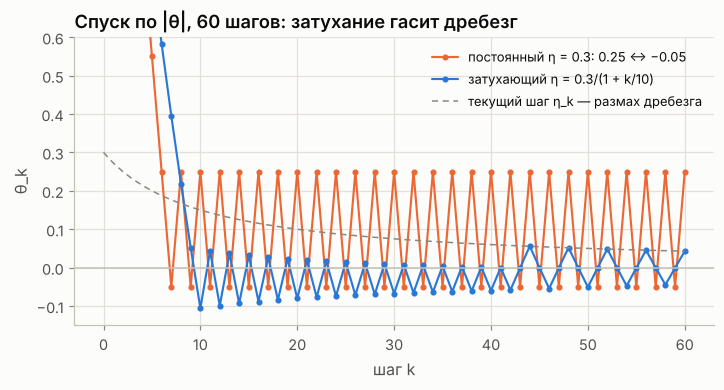

In [22]:
decay_hist = {}
for mode in ("постоянный", "затухающий"):
    t, hist = 2.05, [2.05]
    for k in range(200):
        eta = 0.3 if mode == "постоянный" else 0.3 / (1 + k / 10)
        t -= eta * np.sign(t)  # спуск по |θ|
        hist.append(t)
    decay_hist[mode] = np.array(hist)
    print(f"{mode:10s} темп: |θ| после 60 шагов {abs(hist[60]):.3f}, после 200 — {abs(hist[200]):.3f}")
assert round(abs(decay_hist["затухающий"][60]), 3) == 0.043 and round(abs(decay_hist["затухающий"][200]), 3) == 0.014

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ks = np.arange(61)
ax.plot(ks, decay_hist["постоянный"][:61], marker="o", ms=3, color=ROLE["valid"], lw=1.4,
        label="постоянный η = 0.3: 0.25 ↔ −0.05")
ax.plot(ks, decay_hist["затухающий"][:61], marker="o", ms=3, color=ROLE["train"], lw=1.4,
        label="затухающий η = 0.3/(1 + k/10)")
ax.plot(ks, 0.3 / (1 + ks / 10), color=style.MUTED, ls=(0, (4, 3)), lw=1, label="текущий шаг η_k — размах дребезга")
ax.axhline(0, color=style.AXIS, lw=1)
ax.set(xlabel="шаг k", ylabel="θ_k", ylim=(-0.15, 0.6), title="Спуск по |θ|, 60 шагов: затухание гасит дребезг")
ax.legend(fontsize=8.5)
plt.show()

**Когда остановиться.** Правила: число шагов, маленький наклон, нет улучшения. Квартиры, $\eta = 0.5$, порог
$|f'| < 0.01$: $|f'(c_k)| = 7\cdot0.5^k$ — остановка на 10-м шаге. Порог на наклон — косвенная мера: у
$\theta^4/4$ из $\theta = 1$ с тем же порогом остановка случится далеко от минимума.

In [23]:
stop_flats = gradient_descent(df, 0.0, eta=0.5, tol=0.01)
print(f"|f′| после 9 шагов {abs(df(stop_flats[9])):.4f}, после 10 — {abs(df(stop_flats[10])):.4f}")
print(f"квартиры: остановка на {len(stop_flats) - 1}-м шаге, c = {stop_flats[-1]:.3f}, до минимума {7 - stop_flats[-1]:.4f}")
stop_quart = gradient_descent(lambda t: t**3, 1.0, eta=0.5, tol=0.01)
print(f"θ⁴/4: остановка на {len(stop_quart) - 1}-м шаге, θ = {stop_quart[-1]:.3f} — "
      f"в {stop_quart[-1] / (7 - stop_flats[-1]):.0f} раз дальше от минимума")
assert len(stop_flats) - 1 == 10 and len(stop_quart) - 1 == 18 and round(stop_quart[-1], 3) == 0.211

c, path19 = 0.0, [0.0]
for _ in range(4):
    c -= 1.9 * df(c)
    path19.append(c)
excess = [f(c) - 70 / 12 for c in path19]
print("η = 1.9: c =", np.round(path19, 2), "| f − f* умножается на", np.round(np.array(excess[1:]) / excess[:-1], 2))

|f′| после 9 шагов 0.0137, после 10 — 0.0068
квартиры: остановка на 10-м шаге, c = 6.993, до минимума 0.0068
θ⁴/4: остановка на 18-м шаге, θ = 0.211 — в 31 раз дальше от минимума
η = 1.9: c = [ 0.   13.3   1.33 12.1   2.41] | f − f* умножается на [0.81 0.81 0.81 0.81]


**Кривая потерь — главный прибор.** Значения $f(\theta_k)$ по шагам рассказывают, что не так. Ниже — шесть кривых
виджета «Диагноз по кривой потерь»: прямая для 30 точек (признак стандартизован, подробно — шаги 12–13) с разными
темпами и размерами пакета, спуск по $|\theta|$ и бустинг на 60 точках волны.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


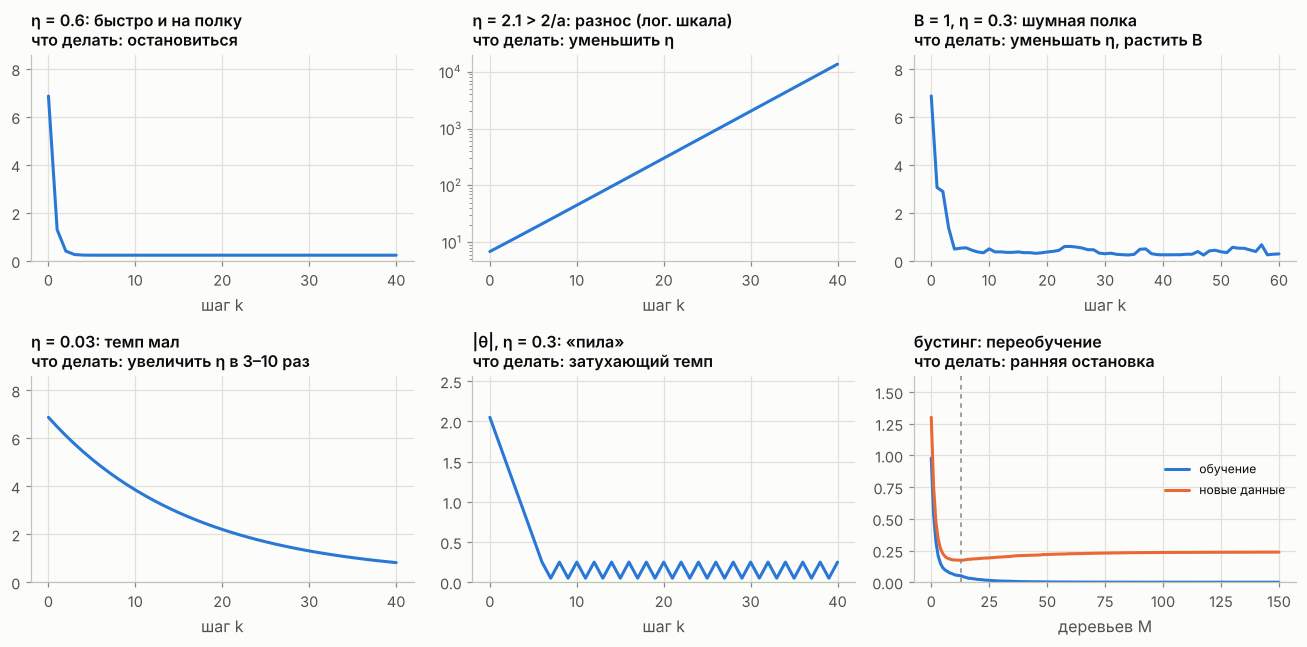

бустинг на 60 точках волны: ошибка на новых данных минимальна при M = 13 (0.1737), после 150 деревьев — 0.2375


In [24]:
X30, y30 = datasets.regression_1d(kind="linear", n=30, noise=0.6, seed=3)
z30 = (X30[:, 0] - X30[:, 0].mean()) / X30[:, 0].std()
half30 = lambda a, b: np.mean((y30 - a * z30 - b) ** 2) / 2  # ½·MSE прямой a·z + b на всех 30 точках


def line_descent(eta, K, B=30, seed=1):
    """Спуск для прямой a·z + b: полный (B = 30) или по мини-пакетам из B точек (шаг 13). Кривая ½·MSE."""
    rng = Mulberry32(seed)
    a = b = 0.0
    hist = [half30(a, b)]
    for _ in range(K):
        idx = rng.sample(30, B) if B < 30 else list(range(30))
        r = y30[idx] - (a * z30[idx] + b)
        a, b = a + eta * np.mean(r * z30[idx]), b + eta * np.mean(r)
        hist.append(half30(a, b))
    return np.array(hist)


Xo, yo = datasets.regression_1d(kind="wave", n=60, noise=0.35, seed=7)
Xv, yv = datasets.regression_1d(kind="wave", n=300, noise=0.35, seed=107)
gb60 = GBRegressor(n_estimators=150, learning_rate=0.3, max_depth=3).fit(Xo, yo)
over_tr = [mse(yo, gb60.predict(Xo, n_iter=m)) for m in range(151)]
over_va = [mse(yv, gb60.predict(Xv, n_iter=m)) for m in range(151)]
t, kink40 = 2.05, [2.05]
for _ in range(40):
    t -= 0.3 * np.sign(t)
    kink40.append(abs(t))

cases = [
    ("η = 0.6: быстро и на полку", [line_descent(0.6, 40)], "остановиться"),
    ("η = 2.1 > 2/a: разнос (лог. шкала)", [line_descent(2.1, 40)], "уменьшить η"),
    ("B = 1, η = 0.3: шумная полка", [line_descent(0.3, 60, B=1)], "уменьшать η, растить B"),
    ("η = 0.03: темп мал", [line_descent(0.03, 40)], "увеличить η в 3–10 раз"),
    ("|θ|, η = 0.3: «пила»", [np.array(kink40)], "затухающий темп"),
    ("бустинг: переобучение", [np.array(over_tr), np.array(over_va)], "ранняя остановка"),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (title, curves, cure) in zip(axes.ravel(), cases):
    for curve, role, label in zip(curves, ("train", "valid"), ("обучение", "новые данные")):
        ax.plot(curve, color=ROLE[role], label=label if len(curves) > 1 else None)
    top = max(c[0] for c in curves) * 1.25
    if "разнос" in title:
        ax.set_yscale("log")  # потери растут в 1.21 раза за шаг — прямая в лог. шкале
    else:
        ax.set(ylim=(0, top))
    ax.set(xlabel="деревьев M" if len(curves) > 1 else "шаг k")
    ax.set_title(f"{title}\nчто делать: {cure}", fontsize=10.5)
    if len(curves) > 1:
        ax.axvline(int(np.argmin(curves[1])), color=style.MUTED, ls=(0, (3, 3)), lw=1)
        ax.legend(fontsize=8, loc="center right")
fig.tight_layout()
plt.show()
print(f"бустинг на 60 точках волны: ошибка на новых данных минимальна при M = {int(np.argmin(over_va))} "
      f"({min(over_va):.4f}), после 150 деревьев — {over_va[-1]:.4f}")

### Шаг 9. Можно ли шагать умнее? Шаг Ньютона

Если знать вторую производную, функцию можно приблизить параболой
$f(\theta + \Delta) \approx f + f'\Delta + \tfrac12 f''\Delta^2$ и прыгнуть в её дно: $\Delta^* = -f'/f''$. Это
**шаг Ньютона** (Newton step) — спуск с темпом $\eta = 1/f''$, пересчитанным в каждой точке. У квартир
$f'' = 1$, и Ньютон совпадает со спуском при $\eta = 1$: из $c = 0$ сразу $c = 7$.

**Пример, к которому мы вернёмся в классификации:** 10 клиентов, 3 не вернули кредит, лучшая константа-логит
$F^* = \ln(0.3/0.7) \approx -0.8473$; $f'(F) = \sigma(F) - 0.3$, $f''(F) = \sigma(F)(1 - \sigma(F))$.

квартиры: Ньютон из 0 → 7
шаг   спуск η = 1        Ньютон   ошибка Ньютона
  1       -0.2000    -0.8000000            0.047
  2       -0.3502    -0.8468680          0.00043
  3       -0.4635    -0.8472978          3.7e-08

Ньютон руками:
 k        F_k   p = σ(F)   f′ = p − 0.3   f″ = p(1 − p)   Δ = −f′/f″
 0     0.0000     0.5000        0.20000          0.2500     -0.80000
 1    -0.8000     0.3100        0.01003          0.2139     -0.04687
 2    -0.8469     0.3001        0.00009          0.2100     -0.00043

шагов до точности 1e−6: {'спуск, η = 1': 58, 'спуск, η = 4': 7, 'Ньютон': 3}


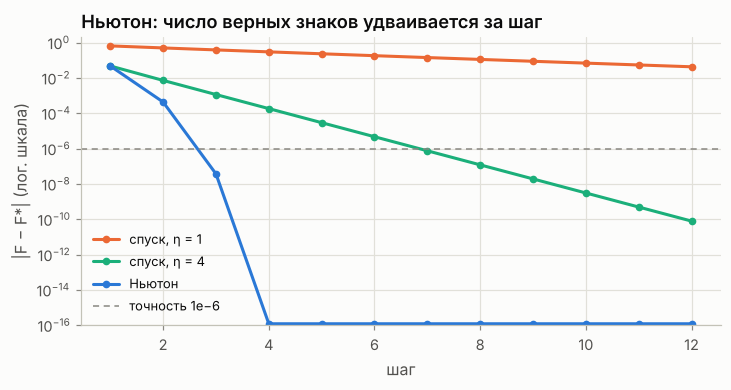

In [25]:
print(f"квартиры: Ньютон из 0 → {0 - df(0) / 1:g}")
steps9 = {"спуск, η = 1": lambda F: F - dll(F), "спуск, η = 4": lambda F: F - 4 * dll(F),
          "Ньютон": lambda F: F - dll(F) / d2ll(F)}
runs = {}
for name, step in steps9.items():
    F, path9 = 0.0, []
    for _ in range(60):
        F = step(F)
        path9.append(F)
    runs[name] = np.array(path9)
print("шаг   спуск η = 1        Ньютон   ошибка Ньютона")
for k in range(3):
    print(f"{k + 1:3d} {runs['спуск, η = 1'][k]:13.4f} {runs['Ньютон'][k]:13.7f} {abs(runs['Ньютон'][k] - F_star):16.2g}")

print("\nНьютон руками:")
print(" k        F_k   p = σ(F)   f′ = p − 0.3   f″ = p(1 − p)   Δ = −f′/f″")
F = 0.0
for k in range(3):
    p = sigmoid(F)
    print(f"{k:2d} {F:10.4f} {p:10.4f} {dll(F):14.5f} {d2ll(F):15.4f} {-dll(F) / d2ll(F):12.5f}")
    F = F - dll(F) / d2ll(F)

need = {name: int(np.argmax(np.abs(r - F_star) < 1e-6)) + 1 for name, r in runs.items()}
print("\nшагов до точности 1e−6:", need)
assert need == {"спуск, η = 1": 58, "спуск, η = 4": 7, "Ньютон": 3}

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for (name, r), color in zip(runs.items(), (ROLE["valid"], ROLE["test"], ROLE["train"])):
    ax.semilogy(np.arange(1, 13), np.abs(r[:12] - F_star) + 1e-17, marker="o", ms=4, color=color, label=name)
ax.axhline(1e-6, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="точность 1e−6")
ax.set(xlabel="шаг", ylabel="|F − F*| (лог. шкала)", ylim=(1e-16, 2),
       title="Ньютон: число верных знаков удваивается за шаг")
ax.legend(fontsize=8.5)
plt.show()

**Ньютон хорош, где $f'' > 0$ и не слишком мала.** Из $F = 2$ на том же log-loss он разлетается; на плоском дне
$\theta^4/4$ лишь умножает $\theta$ на $2/3$ — сходимость линейная, потому что $f''(0) = 0$.

In [26]:
F, wild = 2.0, []
for _ in range(3):
    F = F - dll(F) / d2ll(F)
    wild.append(F)
print("Ньютон на log-loss из F = 2:", np.round(wild, 2))
t, quart_newton = 1.0, []
for _ in range(3):
    t = t - t**3 / (3 * t**2)
    quart_newton.append(t)
print("Ньютон на θ⁴/4 из 1:", np.round(quart_newton, 3))

Ньютон на log-loss из F = 2: [  -3.53    6.3  -376.36]
Ньютон на θ⁴/4 из 1: [0.667 0.444 0.296]


**Тот же шаг в форме сумм: листья XGBoost.** У каждого клиента $g_i = p - y_i$, $h_i = p(1 - p)$, при $p = 0.5$
$G = \sum g_i = 2$, $H = \sum h_i = 2.5$, $-G/H = -0.8$. Штраф $\tfrac12\lambda w^2$ добавляет $\lambda$ к кривизне:
лист $w = -G/(H + \lambda)$. Для ½·MSE все $h_i = 1$, и лист — средний остаток: левый лист пня «площадь ≤ 55»
из урока 1 — квартиры с остатками $-4, -2, -3$.

In [27]:
p = sigmoid(0.0)
g, h = p - yk, np.full(10, p * (1 - p))
G, H = g.sum(), h.sum()
print("g =", g, "\nG =", G, " H =", H)
for lam in (0, 1):
    print(f"λ = {lam}: лист −G/(H + λ) = {-G / (H + lam):.4f}")
left = x <= 55
F7 = np.full(6, 7.0)
G2, H2 = np.sum(F7[left] - y[left]), left.sum()
print(f"пень «площадь ≤ 55», левый лист: остатки {y[left] - 7}, G = {G2:g}, H = {H2}, −G/H = {-G2 / H2:g}")
assert np.isclose(-G / H, -0.8) and np.isclose(-G / (H + 1), -0.5714, atol=1e-4) and -G2 / H2 == -3

g = [-0.5 -0.5 -0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5] 
G = 2.0  H = 2.5
λ = 0: лист −G/(H + λ) = -0.8000
λ = 1: лист −G/(H + λ) = -0.5714
пень «площадь ≤ 55», левый лист: остатки [-4. -2. -3.], G = 9, H = 3, −G/H = -3


> **Привал II: как шагать.**
> - Алгоритм: $\theta \leftarrow \theta - \eta f'(\theta)$, пока наклон не мал. Работает, потому что
>   $f(\theta - \eta f') \approx f - \eta f'^2$.
> - Для параболы множитель $1 - \eta a$: сходимость при $0 < \eta < 2/a$, лучший темп $1/a$, сходимость линейная;
>   в бустинге важна пара $\nu M$.
> - Ловушки: плоское дно, излом, ложные ямы; выпуклость гарантирует глобальный минимум.
> - Темп подбирают сеткой, возвратом, затуханием; диагноз ставят по кривой потерь. Ньютон $-f'/f''$ берёт темп из
>   кривизны — отсюда листья $-G/(H + \lambda)$.

## Часть III. Много параметров

Параметров становится два, потом тысячи. Наклон превращается в вектор — градиент; появляются вытянутые долины,
масштаб признаков и шаги по части данных.

### Шаг 10. Что такое градиент?

**Ящик инструментов: векторы.** Длина $|u| = \sqrt{u_1^2 + u_2^2}$, единичный вектор $u/|u|$, скалярное
произведение $u \cdot v = u_1v_1 + u_2v_2 = |u||v|\cos\varphi$.

In [28]:
u3 = np.array([3.0, 4.0])
print(f"|(3, 4)| = {np.linalg.norm(u3):g}, единичный (0.6, 0.8): {u3 / np.linalg.norm(u3)}, "
      f"(3, 4)·(4, −3) = {u3 @ np.array([4, -3])}, u·u = {u3 @ u3:g} = |u|²")

|(3, 4)| = 5, единичный (0.6, 0.8): [0.6 0.8], (3, 4)·(4, −3) = 0.0, u·u = 25 = |u|²


**Линии уровня, срезы и частные производные.** Чаша $f = \tfrac12(\theta_1^2 + 10\,\theta_2^2)$: линия уровня
$f = 5$ — эллипс с полуосями $\sqrt{10} \approx 3.16$ и 1. В точке $(1, 1)$ срез вдоль $\theta_1$ —
$\tfrac12\theta_1^2 + 5$ (наклон 1), вдоль $\theta_2$ — $\tfrac12 + 5\theta_2^2$ (наклон 10). Наклоны срезов —
**частные производные**, вместе — **градиент** $\nabla f = (1, 10)$. Производная по направлению единичного $u$ —
$\nabla f\cdot u$; она минимальна против градиента ($-|\nabla f|$) и равна нулю вдоль линии уровня. **Направление
спуска** — любое $u$ с $\nabla f\cdot u < 0$.

In [29]:
bowl = lambda t: 0.5 * (t[0] ** 2 + 10 * t[1] ** 2)
grad_bowl = lambda t: np.array([t[0], 10 * t[1]])
t11 = np.array([1.0, 1.0])
print(f"линия уровня f = 5: полуоси √10 = {np.sqrt(10):.2f} и 1")
slices = [central(lambda s, j=j: bowl(t11 + s * np.eye(2)[j]), 0.0) for j in range(2)]  # наклоны срезов
print("наклоны срезов (численно):", np.round(slices, 6), " градиент по формуле:", grad_bowl(t11),
      f" |∇f| = √101 = {np.linalg.norm(grad_bowl(t11)):.2f}")
gr = grad_bowl(t11)
directions = {"(−1, 0)": (-1, 0), "(0, −1)": (0, -1), "(1, 0)": (1, 0),
              "против градиента": -gr / np.linalg.norm(gr), "вдоль линии уровня": np.array([10, -1]) / np.sqrt(101)}
for name, u in directions.items():
    s = gr @ np.asarray(u, float)
    verdict = "спуск" if s < -1e-12 else ("подъём" if s > 1e-12 else "функция не меняется")
    print(f"  направление {name:20s}: ∇f·u = {s:+7.2f} → {verdict}")

линия уровня f = 5: полуоси √10 = 3.16 и 1
наклоны срезов (численно): [ 1. 10.]  градиент по формуле: [ 1. 10.]  |∇f| = √101 = 10.05
  направление (−1, 0)             : ∇f·u =   -1.00 → спуск
  направление (0, −1)             : ∇f·u =  -10.00 → спуск
  направление (1, 0)              : ∇f·u =   +1.00 → подъём
  направление против градиента    : ∇f·u =  -10.05 → спуск
  направление вдоль линии уровня  : ∇f·u =   +0.00 → функция не меняется


**Седловая точка** (saddle point): градиент равен нулю, но это не минимум. У $f = \theta_1^2 - \theta_2^2$ шаг
с $\eta = 0.1$ умножает $\theta_1$ на 0.8 и $\theta_2$ на 1.2. Из $(1, 0.001)$ спуск сначала «сходится», потом
соскальзывает: остановка по малому градиенту на 20-м шаге приняла бы седло за минимум.

через 10 шагов: θ = (0.1074, 0.006), |∇f| = 0.215
через 20 шагов: θ = (0.0115, 0.038), |∇f| = 0.080
через 40 шагов: θ = (0.0001, 1.470), |∇f| = 2.940


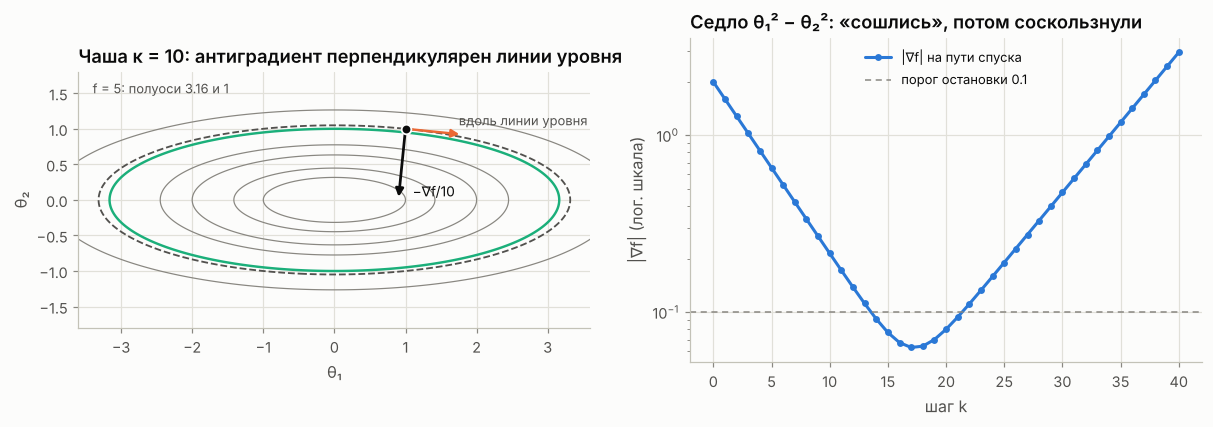

In [30]:
t, saddle = np.array([1.0, 0.001]), [np.array([1.0, 0.001])]
for _ in range(40):
    t = t - 0.1 * np.array([2 * t[0], -2 * t[1]])
    saddle.append(t)
saddle = np.array(saddle)
grad_norm = 2 * np.linalg.norm(saddle, axis=1)  # |∇f| = |(2θ₁, −2θ₂)|
for k in (10, 20, 40):
    print(f"через {k} шагов: θ = ({saddle[k, 0]:.4f}, {saddle[k, 1]:.3f}), |∇f| = {grad_norm[k]:.3f}")
assert round(grad_norm[20], 3) == 0.080 and round(grad_norm[40], 2) == 2.94

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
g1, g2 = np.meshgrid(np.linspace(-3.6, 3.6, 300), np.linspace(-1.8, 1.8, 200))
F2 = 0.5 * (g1**2 + 10 * g2**2)
axes[0].contour(g1, g2, F2, levels=[0.5, 1, 2, 3, 8], colors=style.MUTED, linewidths=0.8)
axes[0].contour(g1, g2, F2, levels=[5], colors=[ROLE["test"]], linewidths=1.6)
axes[0].contour(g1, g2, F2, levels=[5.5], colors=[style.INK_2], linewidths=1.2, linestyles="dashed")
axes[0].annotate("", xy=t11 - 0.1 * gr, xytext=t11, arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=1.8))
axes[0].annotate("", xy=t11 + 0.08 * np.array([10, -1]), xytext=t11,
                 arrowprops=dict(arrowstyle="-|>", color=ROLE["tree"], lw=1.6))
dot(axes[0], [1], [1])
axes[0].text(1.1, 0.05, "−∇f/10", fontsize=9, color=style.INK)
axes[0].text(1.75, 1.05, "вдоль линии уровня", fontsize=8.5, color=style.INK_2)
axes[0].text(-3.4, 1.5, "f = 5: полуоси 3.16 и 1", fontsize=8.5, color=style.INK_2)
axes[0].set(xlabel="θ₁", ylabel="θ₂", aspect="equal", title="Чаша κ = 10: антиградиент перпендикулярен линии уровня")
axes[1].semilogy(grad_norm, marker="o", ms=3.5, color=ROLE["model"], label="|∇f| на пути спуска")
axes[1].axhline(0.1, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="порог остановки 0.1")
axes[1].set(xlabel="шаг k", ylabel="|∇f| (лог. шкала)", title="Седло θ₁² − θ₂²: «сошлись», потом соскользнули")
axes[1].legend(fontsize=8.5)
fig.tight_layout()
plt.show()

### Шаг 11. Почему спуск зигзагует?

Один темп общий для всех направлений. Чаша $\tfrac12(\theta_1^2 + 10\theta_2^2)$ — две независимые параболы
с кривизнами 1 и 10: с $\eta = 0.15$ множители $1 - \eta = 0.85$ и $1 - 10\eta = -0.5$. Отношение наибольшей
кривизны к наименьшей — **число обусловленности** (condition number) $\kappa$. Даже с лучшим постоянным темпом
$2/(1 + \kappa)$ шагов нужно примерно $3.45\kappa$ до точности 0.1 %.

In [31]:
t = np.array([1.0, 1.0])
print("шаг    θ₁ (×0.85)   θ₂ (×−0.5)       f")
for k in range(4):
    print(f"{k:3d} {t[0]:12.4f} {t[1]:12.3f} {bowl(t):9.3f}")
    t = t - 0.15 * grad_bowl(t)


def bowl_steps(kappa, eta, beta=0.0, t0=(2.5, 1.0), max_steps=5000):
    """Шагов спуска (с инерцией β) по чаше ½(θ₁² + κθ₂²) до точности 0.1 %; путь — вторым значением."""
    t0 = np.array(t0)
    t, v, path_b = t0.copy(), np.zeros(2), [t0.copy()]
    for k in range(1, max_steps + 1):
        v = beta * v - eta * np.array([t[0], kappa * t[1]])  # v ← βv − η∇f
        t = t + v  # θ ← θ + v
        path_b.append(t.copy())
        if np.linalg.norm(t) < 1e-3 * np.linalg.norm(t0):
            return k, np.array(path_b)
        if np.linalg.norm(t) > 1e6:
            return "разнос", np.array(path_b)
    return f"> {max_steps}", np.array(path_b)


print("\n  κ   лучший постоянный η   шагов   ≈ 3.45κ")
for kappa in (10, 100):
    n = bowl_steps(kappa, 2 / (1 + kappa))[0]
    print(f"{kappa:3d} {2 / (1 + kappa):18.4f} {n:8d} {np.log(1000) / 2 * kappa:8.1f}")
assert bowl_steps(10, 2 / 11)[0] == 35 and bowl_steps(100, 2 / 101)[0] == 346

шаг    θ₁ (×0.85)   θ₂ (×−0.5)       f
  0       1.0000        1.000     5.500
  1       0.8500       -0.500     1.611
  2       0.7225        0.250     0.574
  3       0.6141       -0.125     0.267

  κ   лучший постоянный η   шагов   ≈ 3.45κ
 10             0.1818       35     34.5
100             0.0198      346    345.4


**Инерция** (momentum): $v \leftarrow \beta v - \eta\nabla f$, $\theta \leftarrow \theta + v$. Вдоль долины шаги
складываются, поперёк — гасят друг друга. Инерция расширяет допустимую зону до $\eta < 2(1 + \beta)/\kappa$, а с
наилучшими $\eta = \big(2/(1 + \sqrt\kappa)\big)^2$ и $\beta = \big((\sqrt\kappa - 1)/(\sqrt\kappa + 1)\big)^2$
число шагов растёт как $\sqrt\kappa$.

  η     β   шагов до 0.1 %
0.15     0   43
0.15   0.5   18
 0.2     0   > 5000
 0.2   0.5   20
граница с инерцией: 2(1 + β)/κ = 0.3; η = 0.29 → 21, η = 0.31 → разнос
κ = 10: лучшие η = 0.2309, β = 0.2699 → шагов до 0.1 %: 15
κ = 100: лучшие η = 0.0331, β = 0.6694 → шагов до 0.1 %: 53


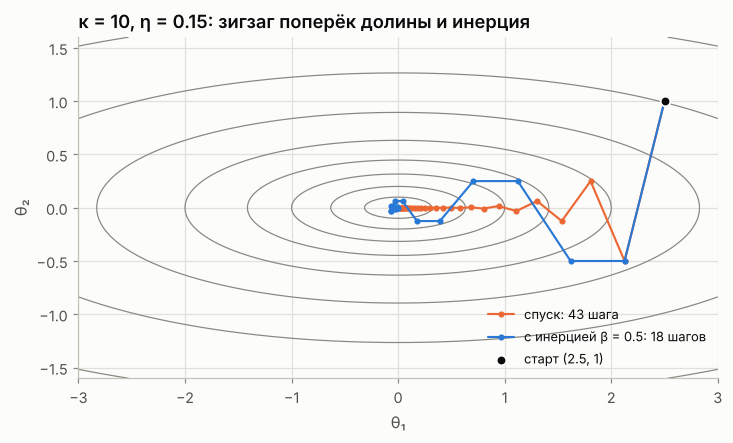

In [32]:
print("  η     β   шагов до 0.1 %")
for eta, beta in ((0.15, 0), (0.15, 0.5), (0.2, 0), (0.2, 0.5)):
    print(f"{eta:4g} {beta:5g}   {bowl_steps(10, eta, beta)[0]}")
print(f"граница с инерцией: 2(1 + β)/κ = {2 * 1.5 / 10:g}; η = 0.29 → {bowl_steps(10, 0.29, 0.5)[0]}, "
      f"η = 0.31 → {bowl_steps(10, 0.31, 0.5)[0]}")
for kappa in (10, 100):
    s = np.sqrt(kappa)
    eta_b, beta_b = (2 / (1 + s)) ** 2, ((s - 1) / (s + 1)) ** 2
    print(f"κ = {kappa}: лучшие η = {eta_b:.4f}, β = {beta_b:.4f} → шагов до 0.1 %: {bowl_steps(kappa, eta_b, beta_b)[0]}")
assert [bowl_steps(10, 0.15)[0], bowl_steps(10, 0.15, 0.5)[0], bowl_steps(10, 0.2, 0.5)[0]] == [43, 18, 20]

g1, g2 = np.meshgrid(np.linspace(-3, 3, 240), np.linspace(-1.6, 1.6, 140))
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.contour(g1, g2, 0.5 * (g1**2 + 10 * g2**2), levels=[0.05, 0.2, 0.5, 1, 2, 4, 8, 16], colors=style.MUTED,
           linewidths=0.8)
for beta, color, name in ((0.0, ROLE["tree"], "спуск: 43 шага"), (0.5, ROLE["model"], "с инерцией β = 0.5: 18 шагов")):
    pb = bowl_steps(10, 0.15, beta)[1][:30]
    ax.plot(pb[:, 0], pb[:, 1], marker="o", ms=3, color=color, lw=1.4, label=name)
dot(ax, [2.5], [1.0], label="старт (2.5, 1)")
ax.set(xlabel="θ₁", ylabel="θ₂", aspect="equal", title="κ = 10, η = 0.15: зигзаг поперёк долины и инерция")
ax.legend(fontsize=8.5, loc="lower right")
plt.show()

### Шаг 12. Зачем нормировать признаки?

Подгоним к квартирам прямую $F(x) = ax + b$, $f(a, b) = \tfrac12\cdot\text{MSE}$. Частные производные:
$\partial f/\partial a = -\frac1n\sum r_i x_i$, $\partial f/\partial b = -\frac1n\sum r_i$, где $r_i$ — остаток.
В точке $(0, 0)$ остатки равны ценам, $\sum x_iy_i = 2640$.

In [33]:
X6 = np.c_[x, np.ones(6)]  # столбцы: площадь и единица (для b)
grad0 = -X6.T @ y / 6
print(f"Σ xᵢyᵢ = {np.sum(x * y):g};  ∇f(0, 0) = {grad0};  наклон по a круче в {grad0[0] / grad0[1]:.1f} раза")

Σ xᵢyᵢ = 2640;  ∇f(0, 0) = [-440.   -7.];  наклон по a круче в 62.9 раза


**Пример руками.** Площадь «в десятках метров от середины»: $u = (x - 55)/10$. Тогда $\bar u = 0$,
$\overline{u^2} = 17.5/6 \approx 2.917$, $\overline{uy} = 5.5$, и производные распадаются:
$\partial f/\partial a = 2.917a - 5.5$, $\partial f/\partial b = b - 7$. Спуск с $\eta = 0.5$.

In [34]:
u = (x - 55) / 10
print("u =", u, f"  mean u² = {np.mean(u * u):.3f}, mean u·y = {np.mean(u * y):g}")
a = b = 0.0
print(" k       a       b    ½·MSE   ∇f = (∂a, ∂b)")
for k in range(4):
    r = y - (a * u + b)
    ga, gb = -np.mean(r * u), -np.mean(r)
    print(f"{k:2d} {a:7.3f} {b:7.3f} {np.mean(r**2) / 2:8.3f}   ({ga:.3f}, {gb:.3f})")
    a, b = a - 0.5 * ga, b - 0.5 * gb
a_u = np.mean(u * y) / np.mean(u * u)
print(f"оптимум: a = {a_u:.3f}, b = 7, ½·MSE = {np.mean((y - a_u * u - 7) ** 2) / 2:.3f}")
print(f"множитель по a: 1 − 0.5·2.917 = {1 - 0.5 * np.mean(u * u):.3f}; лучший темп для a: 1/2.917 = {1 / np.mean(u * u):.3f}")
print(f"обратно к площадям: наклон {a_u / 10:.4f} млн за м², сдвиг 7 − {a_u:.3f}·5.5 = {7 - a_u * 5.5:.3f}")

u = [-2.5 -1.5 -0.5  0.5  1.5  2.5]   mean u² = 2.917, mean u·y = 5.5
 k       a       b    ½·MSE   ∇f = (∂a, ∂b)
 0   0.000   0.000   30.333   (-5.500, -7.000)
 1   2.750   3.500    7.862   (2.521, -3.500)
 2   1.490   5.250    2.408   (-1.155, -1.750)
 3   2.067   6.125    1.079   (0.530, -0.875)
оптимум: a = 1.886, b = 7, ½·MSE = 0.648
множитель по a: 1 − 0.5·2.917 = -0.458; лучший темп для a: 1/2.917 = 0.343
обратно к площадям: наклон 0.1886 млн за м², сдвиг 7 − 1.886·5.5 = -3.371


**Сырые площади: две беды.** Масштаб ($\partial^2 f/\partial a^2 = \overline{x^2} \approx 3317$ против 1) и наклон
долины (смешанная производная $\bar x = 55 \ne 0$). Главные кривизны — собственные числа матрицы вторых
производных; их отношение — $\kappa$. Центрирование убирает поворот, стандартизация — и растяжение.

mean x² = 3316.7, mean x = 55, стандартное отклонение площадей 17.08
как есть: x                        кривизны    0.0879 и  3317.58  κ =    37736.0
центрировать: x − 55               кривизны    1.0000 и   291.67  κ =      291.7
стандартизовать: (x − 55)/17.08    кривизны    1.0000 и     1.00  κ =        1.0
безопасный темп для сырых площадей: η < 2/3318 = 0.0006
5000 шагов с η = 0.0005: a = 0.1437, b = -0.6635 (МНК: 0.1886, −3.3714); пройдена доля 1 − (1 − 0.0005·0.088)^5000 = 20% пути вдоль дна


как есть: x                        лучший η = 0.000603: шагов до 0.1 % — 130336
центрировать: x − 55               лучший η = 0.006834: шагов до 0.1 % — 1008
стандартизовать: (x − 55)/17.08    лучший η = 1.000000: шагов до 0.1 % — 1


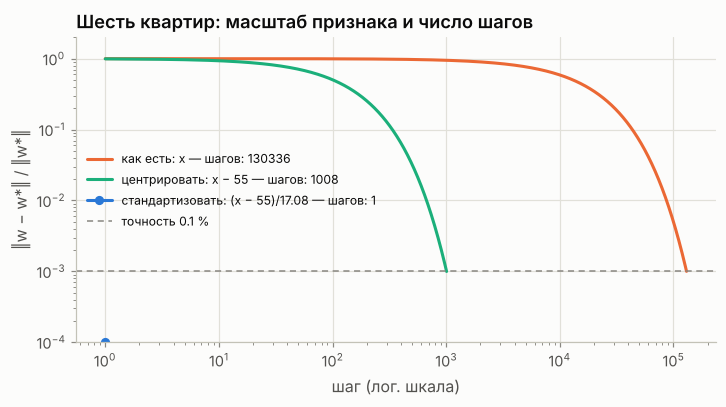

In [35]:
def curvatures(v):
    """Главные кривизны ½·MSE прямой a·v + b: собственные числа [[mean v², mean v], [mean v, 1]]."""
    return np.linalg.eigvalsh(np.array([[np.mean(v * v), np.mean(v)], [np.mean(v), 1.0]]))


scalings = {"как есть: x": x, "центрировать: x − 55": x - 55, "стандартизовать: (x − 55)/17.08": (x - 55) / x.std()}
print(f"mean x² = {np.mean(x * x):.1f}, mean x = {x.mean():g}, стандартное отклонение площадей {x.std():.2f}")
kappas = {}
for name, v in scalings.items():
    lo, hi = curvatures(v)
    kappas[name] = hi / lo
    print(f"{name:34s} кривизны {lo:9.4f} и {hi:8.2f}  κ = {hi / lo:10.1f}")
lo_raw, hi_raw = curvatures(x)
print(f"безопасный темп для сырых площадей: η < 2/{hi_raw:.0f} = {2 / hi_raw:.4f}")
assert [round(k, 1) for k in kappas.values()] == [37736.0, 291.7, 1.0]

a = b = 0.0
for _ in range(5000):
    r = y - (a * x + b)
    a, b = a + 5e-4 * np.mean(r * x), b + 5e-4 * np.mean(r)  # шаг против градиента ½·MSE
print(f"5000 шагов с η = 0.0005: a = {a:.4f}, b = {b:.4f} (МНК: 0.1886, −3.3714); "
      f"пройдена доля 1 − (1 − 0.0005·{lo_raw:.3f})^5000 = {1 - (1 - 5e-4 * lo_raw) ** 5000:.0%} пути вдоль дна")
assert round(a, 4) == 0.1437 and round(b, 4) == -0.6635


def steps_to_optimum(v, eta, tol=1e-3, max_steps=200_000):
    """Спуск для прямой a·v + b из (0, 0): шагов до ‖w − w*‖ < tol·‖w*‖ и относительное расстояние по шагам."""
    m1, m2, my, mvy = np.mean(v), np.mean(v * v), np.mean(y), np.mean(v * y)
    a_opt = (mvy - m1 * my) / (m2 - m1 * m1)
    b_opt = my - a_opt * m1
    d0 = np.hypot(a_opt, b_opt)
    a = b = 0.0
    dist = [1.0]
    for k in range(1, max_steps + 1):
        ga, gb = m2 * a + m1 * b - mvy, m1 * a + b - my  # ∂f/∂a, ∂f/∂b
        a, b = a - eta * ga, b - eta * gb
        dist.append(np.hypot(a - a_opt, b - b_opt) / d0)
        if dist[-1] < tol:
            return k, np.array(dist)
    return None, np.array(dist)


best_runs = {}
for name, v in scalings.items():
    lo, hi = curvatures(v)
    eta_best = 2 / (lo + hi)  # лучший постоянный темп
    n, dist = steps_to_optimum(v, eta_best)
    best_runs[name] = dist
    print(f"{name:34s} лучший η = {eta_best:.6f}: шагов до 0.1 % — {n}")
assert len(best_runs["как есть: x"]) - 1 == 130336

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for (name, dist), color in zip(best_runs.items(), (ROLE["valid"], ROLE["test"], ROLE["train"])):
    ks = np.arange(len(dist))
    ax.loglog(ks[1:], np.maximum(dist[1:], 1e-4), color=color, marker="o" if len(dist) < 5 else None,
              label=f"{name} — шагов: {len(dist) - 1}")
ax.axhline(1e-3, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="точность 0.1 %")
ax.set(xlabel="шаг (лог. шкала)", ylabel="‖w − w*‖ / ‖w*‖", ylim=(1e-4, 2),
       title="Шесть квартир: масштаб признака и число шагов")
ax.legend(fontsize=8)
plt.show()

То же на 30 зашумлённых точках виджета 2D-спуска: переключайте масштаб признака — $\kappa$ падает с 150 до 7.4
и до 1. Деревьям — и бустингу над ними — масштаб безразличен: они сравнивают значения с порогами.

In [36]:
x30 = X30[:, 0]
for name, v in (("как есть", x30), ("центрированный", x30 - x30.mean()), ("стандартизованный", z30)):
    lo, hi = curvatures(v)
    print(f"30 точек, признак {name:18s}: κ = {hi / lo:.2f}")

30 точек, признак как есть          : κ = 150.45
30 точек, признак центрированный    : κ = 7.39
30 точек, признак стандартизованный : κ = 1.00


### Шаг 13. Нужны ли все данные для шага?

**Стохастический градиентный спуск** (SGD) считает градиент по случайной части объектов — **мини-пакету**
(mini-batch) из $B$ объектов. В среднем такой шаг совпадает с полным.

**Ступень 1: одно число.** Пакет $B = 1$: $c \leftarrow c + \eta(y_i - c)$. Квартиры выбирает `Mulberry32(1)` —
тот же генератор, что в виджете, поэтому последовательности совпадают с браузером.

In [37]:
print("шаг по одной квартире из c = 0, η = 0.5:", 0.5 * y, "— среднее", np.mean(0.5 * y), "= полный шаг 3.5")
print("из c = 7 (полный градиент равен нулю):", 7 + 0.5 * (y - 7))
sgd_c = {}
for mode in ("η = 0.5", "η = 1/(k + 1)"):
    rng, c, picked, cpath = Mulberry32(1), 0.0, [], [0.0]
    for k in range(60):
        i = rng.sample(6, 1)[0]  # одна случайная квартира
        eta = 0.5 if mode == "η = 0.5" else 1 / (k + 1)
        c = c + eta * (y[i] - c)
        picked.append(y[i])
        cpath.append(c)
    sgd_c[mode] = np.array(cpath)
    print(f"{mode:13s}: цены {[int(v) for v in picked[:6]]}, c = {np.round(cpath[1:7], 2)}")
    if mode != "η = 0.5":
        print(f"{'':15s}среднее выбранных цен: {np.round(np.cumsum(picked[:6]) / np.arange(1, 7), 2)} — то же самое")
assert np.allclose(sgd_c["η = 1/(k + 1)"][1:], np.cumsum(picked) / np.arange(1, 61))

шаг по одной квартире из c = 0, η = 0.5: [1.5 2.5 2.  4.  4.5 6.5] — среднее 3.5 = полный шаг 3.5
из c = 7 (полный градиент равен нулю): [ 5.   6.   5.5  7.5  8.  10. ]
η = 0.5      : цены [8, 3, 8, 13, 13, 5], c = [ 4.    3.5   5.75  9.38 11.19  8.09]
η = 1/(k + 1): цены [8, 3, 8, 13, 13, 5], c = [8.   5.5  6.33 8.   9.   8.33]
               среднее выбранных цен: [8.   5.5  6.33 8.   9.   8.33] — то же самое


**Ступень 2: прямая для 30 точек** (признак стандартизован, $\eta = 0.1$, 60 шагов). **Эпоха** (epoch) — один
проход по всем данным: при $B = 1$ это 30 шагов SGD или один шаг полного спуска.

In [38]:
a_opt30, b_opt30 = np.mean(z30 * (y30 - y30.mean())), y30.mean()
opt30 = half30(a_opt30, b_opt30)
print(f"минимум ½·MSE = {opt30:.5f}")
print(" B   ½·MSE на 60-м шаге   за последние 20 шагов   просмотрено точек")
sgd_runs = {}
for B in (1, 5, 30):
    hist = line_descent(0.1, 60, B=B)
    sgd_runs[B] = hist
    print(f"{B:2d} {hist[-1]:16.5f} {hist[-20:].min():14.4f}–{hist[-20:].max():.4f} {60 * B:12d} (эпох: {2 * B})")
assert round(sgd_runs[1][-1], 4) == 0.2547 and round(sgd_runs[5][-1], 4) == 0.2409
print(f"при равной стоимости: 2 эпохи — полный спуск {sgd_runs[30][2]:.3f} против {sgd_runs[1][-1]:.4f} у B = 1; "
      f"10 эпох — {sgd_runs[30][10]:.3f} против {sgd_runs[5][-1]:.4f} у B = 5")

минимум ½·MSE = 0.23688
 B   ½·MSE на 60-м шаге   за последние 20 шагов   просмотрено точек
 1          0.25468         0.2390–0.3338           60 (эпох: 2)
 5          0.24091         0.2380–0.2524          300 (эпох: 10)
30          0.23690         0.2369–0.2381         1800 (эпох: 60)
при равной стоимости: 2 эпохи — полный спуск 4.590 против 0.2547 у B = 1; 10 эпох — 1.044 против 0.2409 у B = 5


**Цена дешевизны — шум.** «Дрожание» у минимума примерно пропорционально $\eta/B$. Средний избыток ½·MSE над
минимумом в установившемся режиме оценим по 40 зёрнам `Mulberry32(1…40)`: 400 шагов, среднее по последним 200.

In [39]:
print(" B     η   средний избыток ½·MSE над минимумом")
noise = {}
for B in (1, 5):
    for eta in (0.1, 0.05):
        excess = [np.mean(line_descent(eta, 400, B=B, seed=s)[-200:]) - opt30 for s in range(1, 41)]
        noise[B, eta] = np.mean(excess)
        print(f"{B:2d} {eta:5g} {noise[B, eta]:12.4f}")
print(f"B = 5 тише B = 1 в {noise[1, 0.1] / noise[5, 0.1]:.1f} и {noise[1, 0.05] / noise[5, 0.05]:.1f} раза")
assert [round(noise[k], 3) for k in ((1, 0.1), (1, 0.05), (5, 0.1))] == [0.032, 0.015, 0.005]
assert round(noise[5, 0.05], 4) == 0.0025

 B     η   средний избыток ½·MSE над минимумом


 1   0.1       0.0322


 1  0.05       0.0152


 5   0.1       0.0051


 5  0.05       0.0025
B = 5 тише B = 1 в 6.3 и 6.2 раза


**Условие Роббинса — Монро.** Шумному шагу мало $\eta_k \to 0$ и $\sum\eta_k = \infty$: нужно ещё
$\sum\eta_k^2 < \infty$, чтобы накопленный шум затих. Шесть квартир, 2000 шагов SGD с $B = 1$ из $c_0 = 0$, средняя
ошибка $|c - 7|$ по 40 запускам (seed 1…40).

0.1 (постоянный)  средняя |c − 7| = 0.545


1/√(k + 1)        средняя |c − 7| = 0.310
0.5/(k + 1)^0.6   средняя |c − 7| = 0.153


1/(k + 1)         средняя |c − 7| = 0.067


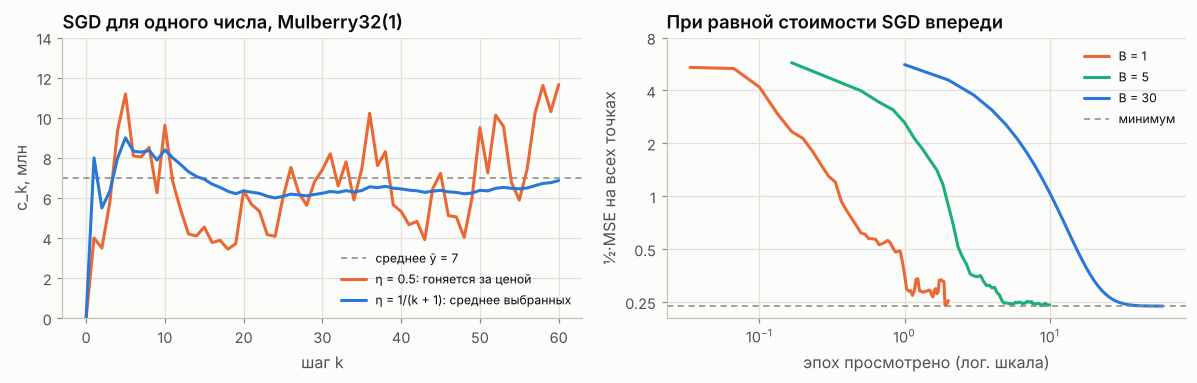

In [40]:
schedules = {
    "0.1 (постоянный)": lambda k: 0.1,
    "1/√(k + 1)": lambda k: 1 / np.sqrt(k + 1),
    "0.5/(k + 1)^0.6": lambda k: 0.5 / (k + 1) ** 0.6,
    "1/(k + 1)": lambda k: 1 / (k + 1),
}
rm = {}
for name, eta_k in schedules.items():
    errs = []
    for seed in range(1, 41):
        rng, c = Mulberry32(seed), 0.0
        for k in range(2000):
            i = rng.sample(6, 1)[0]
            c = c + eta_k(k) * (y[i] - c)
        errs.append(abs(c - 7))
    rm[name] = np.mean(errs)
    print(f"{name:17s} средняя |c − 7| = {rm[name]:.3f}")
assert [round(v, 3) for v in rm.values()] == [0.545, 0.31, 0.153, 0.067]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].axhline(7, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="среднее ȳ = 7")
axes[0].plot(sgd_c["η = 0.5"], color=ROLE["valid"], label="η = 0.5: гоняется за ценой")
axes[0].plot(sgd_c["η = 1/(k + 1)"], color=ROLE["train"], label="η = 1/(k + 1): среднее выбранных")
axes[0].set(xlabel="шаг k", ylabel="c_k, млн", ylim=(0, 14), title="SGD для одного числа, Mulberry32(1)")
for B, color in zip((1, 5, 30), (ROLE["valid"], ROLE["test"], ROLE["train"])):
    epochs = np.arange(1, 61) * B / 30  # после k шагов просмотрено k·B точек
    axes[1].loglog(epochs, sgd_runs[B][1:], color=color, label=f"B = {B}")
axes[1].axhline(opt30, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="минимум")
axes[1].set_yticks([0.25, 0.5, 1, 2, 4, 8], labels=["0.25", "0.5", "1", "2", "4", "8"])
axes[1].minorticks_off()
axes[1].set(xlabel="эпох просмотрено (лог. шкала)", ylabel="½·MSE на всех точках",
            title="При равной стоимости SGD впереди")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

> **Привал III: много параметров.**
> - Частная производная — наклон среза; градиент — вектор наклонов, перпендикулярный линии уровня; $-\nabla f$ —
>   самый крутой спуск.
> - Вытянутость $\kappa$ замедляет спуск примерно в $\kappa$ раз; лечат нормировкой признаков и инерцией.
> - SGD шагает по части данных: дёшево и шумно. В бустинге — `subsample`.

## Часть IV. Мост к бустингу

Главный поворот урока: параметрами становятся сами прогнозы, а шаг делает дерево.

### Шаг 14. Что, если параметры — сами прогнозы?

Пусть параметры — прогнозы $F_i = F(x_i)$ на обучающих объектах. Антиградиент $\tfrac12\sum(y_i - F_i)^2$ по
$F_i$ — остаток $y_i - F_i$, и свободный шаг $F_i \leftarrow F_i + \nu(y_i - F_i)$ двигает каждый прогноз
отдельно. Шаг-дерево приближает вектор антиградиента функцией от $x$ — пнём с порогом 55. Дерево — не самый
крутой спуск, но направление спуска: $h\cdot r > 0$.

In [41]:
F0 = np.full(6, y.mean())
r = y - F0  # антиградиент ½·Σ(y − F)²
print("антиградиент r =", r, " ‖r‖² =", r @ r)
free = F0 + 0.5 * r
print("свободный шаг: прогнозы", free, " сумма квадратов", np.sum((y - free) ** 2), "| квартира 65 м² →", y.mean())


def stump(r, t):
    """Пень на остатках: средние слева и справа от порога t (без разбиения — нули)."""
    if (x <= t).all() or (x > t).all():
        return np.zeros_like(r)
    return np.where(x <= t, r[x <= t].mean(), r[x > t].mean())


h = stump(r, 55)
cos = h @ r / np.linalg.norm(h) / np.linalg.norm(r)
print("шаг-пень: h =", h, f" сумма квадратов после шага {np.sum((r - 0.5 * h) ** 2):g}, "
      f"квартира 65 м² → {y.mean() + 0.5 * r[x > 55].mean():g}")
print(f"h·r = {h @ r:g} > 0, cos(h, r) = {cos:.3f}; ‖h‖² = {h @ h:g} = h·r")
print(f"‖r − νh‖² = 70 − (2ν − ν²)·h·r = 70 − 0.75·54 = {70 - 0.75 * 54:g}; "
      f"лучшая длина шага ρ* = h·r/‖h‖² = {(h @ r) / (h @ h):g}")
assert np.isclose(np.sum((r - 0.5 * h) ** 2), 29.5) and round(cos, 3) == 0.878

антиградиент r = [-4. -2. -3.  1.  2.  6.]  ‖r‖² = 70.0
свободный шаг: прогнозы [ 5.   6.   5.5  7.5  8.  10. ]  сумма квадратов 17.5 | квартира 65 м² → 7.0
шаг-пень: h = [-3. -3. -3.  3.  3.  3.]  сумма квадратов после шага 29.5, квартира 65 м² → 8.5
h·r = 54 > 0, cos(h, r) = 0.878; ‖h‖² = 54 = h·r
‖r − νh‖² = 70 − (2ν − ν²)·h·r = 70 − 0.75·54 = 29.5; лучшая длина шага ρ* = h·r/‖h‖² = 1


**Почему не спускаться по порогу дерева.** Сумма квадратов после шага пнём как функция порога $t$ — ступеньки:
внутри интервала производная по $t$ равна нулю, на стыках её нет. Поэтому пороги перебирают, а производные берут
по прогнозам.

t ∈ [30, 40): сумма квадратов 50.8
t ∈ [40, 50): сумма квадратов 43.0
t ∈ [50, 60): сумма квадратов 16.0
t ∈ [60, 70): сумма квадратов 22.0
t ∈ [70, 80): сумма квадратов 26.8
без разбиения: 70


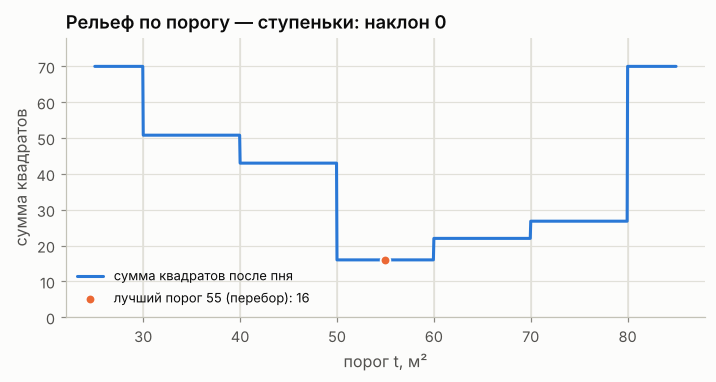

In [42]:
for lo_t, hi_t in ((30, 40), (40, 50), (50, 60), (60, 70), (70, 80)):
    t_mid = (lo_t + hi_t) / 2
    print(f"t ∈ [{lo_t}, {hi_t}): сумма квадратов {np.sum((r - stump(r, t_mid)) ** 2):.1f}")
print(f"без разбиения: {np.sum((r - stump(r, 25)) ** 2):g}")

ts = np.linspace(25, 85, 1201)
sse_t = [np.sum((r - stump(r, t)) ** 2) for t in ts]
fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.plot(ts, sse_t, color=ROLE["model"], label="сумма квадратов после пня")
for xa in x:
    ax.axvline(xa, color=style.GRID, lw=1, zorder=0)
dot(ax, [55], [16], color=ROLE["tree"], label="лучший порог 55 (перебор): 16")
ax.set(xlabel="порог t, м²", ylabel="сумма квадратов", ylim=(0, 78), title="Рельеф по порогу — ступеньки: наклон 0")
ax.legend(fontsize=8.5)
plt.show()

**Три шага: свободно и через пни** ($\nu = 0.5$; пень каждый раз строится заново по текущим остаткам, порог —
перебором). Следим за обучающей квартирой 80 м² ($y = 13$) и новой 65 м², которой в обучении нет.

In [43]:
def best_stump(r):
    """Лучший пень по перебору порогов-середин: (порог, h на обучающих x)."""
    cands = (x[:-1] + x[1:]) / 2
    t_best = min(cands, key=lambda t: np.sum((r - stump(r, t)) ** 2))
    return t_best, stump(r, t_best)


F_free, F_tree, new65 = F0.copy(), F0.copy(), y.mean()
print("шаг | свободно: сумма кв.  80 м²  65 м² | пни: сумма кв.  80 м²  65 м²  порог  cos(h, r)")
for k in range(4):
    rr = y - F_tree
    t_k, h_k = best_stump(rr)
    cos_k = h_k @ rr / np.linalg.norm(h_k) / np.linalg.norm(rr)
    print(f"{k:3d} | {np.sum((y - F_free) ** 2):17.3f} {F_free[-1]:6.2f} {y.mean():6.2f} | "
          f"{np.sum(rr**2):13.3f} {F_tree[-1]:6.2f} {new65:6.2f} {t_k:6.0f} {cos_k:9.3f}")
    F_free = F_free + 0.5 * (y - F_free)
    F_tree = F_tree + 0.5 * h_k
    new65 += 0.5 * (rr[x <= t_k].mean() if 65 <= t_k else rr[x > t_k].mean())  # пень — функция от площади

шаг | свободно: сумма кв.  80 м²  65 м² | пни: сумма кв.  80 м²  65 м²  порог  cos(h, r)
  0 |            70.000   7.00   7.00 |        70.000   7.00   7.00     55     0.878
  1 |            17.500  10.00   7.00 |        29.500   8.50   8.50     75     0.908
  2 |             4.375  11.50   7.00 |        11.275  10.75   8.05     65     0.825
  3 |             1.094  12.25   7.00 |         5.515  11.55   7.65     35     0.770


**Двенадцать точек волны.** Свободный спуск по прогнозам против спуска через дерево глубины 2 (это и есть
градиентный бустинг, `GBRegressor`). Новые точки — 200 точек того же генератора с другим зерном.

In [44]:
Xw, yw = datasets.regression_1d(kind="wave", n=12, noise=0.3, seed=3)
Xt, yt = datasets.regression_1d(kind="wave", n=200, noise=0.3, seed=103)
nu, K = 0.3, 40
F = np.full_like(yw, yw.mean())
free_tr = [mse(yw, F)]
for _ in range(K):
    F = F + nu * (yw - F)  # шаг по антиградиенту: остатки
    free_tr.append(mse(yw, F))
free_te = mse(yt, np.full_like(yt, yw.mean()))  # новым точкам свободный спуск ничего не сказал
gb = GBRegressor(n_estimators=K, learning_rate=nu, max_depth=2).fit(Xw, yw)
gb_tr = [mse(yw, gb.predict(Xw, n_iter=k)) for k in range(K + 1)]
gb_te = [mse(yt, gb.predict(Xt, n_iter=k)) for k in range(K + 1)]
k_best = int(np.argmin(gb_te))
print(f"20 шагов: свободно — обучение {free_tr[20]:.4f}, новые {free_te:.4f}; "
      f"через дерево — обучение {gb_tr[20]:.4f}, новые {gb_te[20]:.4f}")
print(f"через дерево: минимум на новых точках при k = {k_best}: {gb_te[k_best]:.4f}; "
      f"к 40 шагам {gb_te[40]:.4f} (на обучении {gb_tr[40]:.4f})")
assert round(free_te, 4) == 1.4441 and round(gb_te[20], 4) == 0.2368 and k_best == 10
assert round(gb_te[10], 4) == 0.2196 and round(gb_te[40], 4) == 0.2531

20 шагов: свободно — обучение 0.0000, новые 1.4441; через дерево — обучение 0.0055, новые 0.2368
через дерево: минимум на новых точках при k = 10: 0.2196; к 40 шагам 0.2531 (на обучении 0.0002)


**Почему $\nu$ берут маленьким.** Для каждого темпа найдём лучшее число деревьев по ошибке на новых точках
(ранняя остановка) и посмотрим, что будет при вдвое большем числе деревьев.

ν = 1   : лучшее M =   4, ν·M = 4.00, MSE 0.2439; при 2M деревьях 0.2606
ν = 0.5 : лучшее M =   6, ν·M = 3.00, MSE 0.2215; при 2M деревьях 0.2383
ν = 0.3 : лучшее M =  10, ν·M = 3.00, MSE 0.2196; при 2M деревьях 0.2368


ν = 0.1 : лучшее M =  35, ν·M = 3.50, MSE 0.2168; при 2M деревьях 0.2358


ν = 0.03: лучшее M = 118, ν·M = 3.54, MSE 0.2161; при 2M деревьях 0.2353


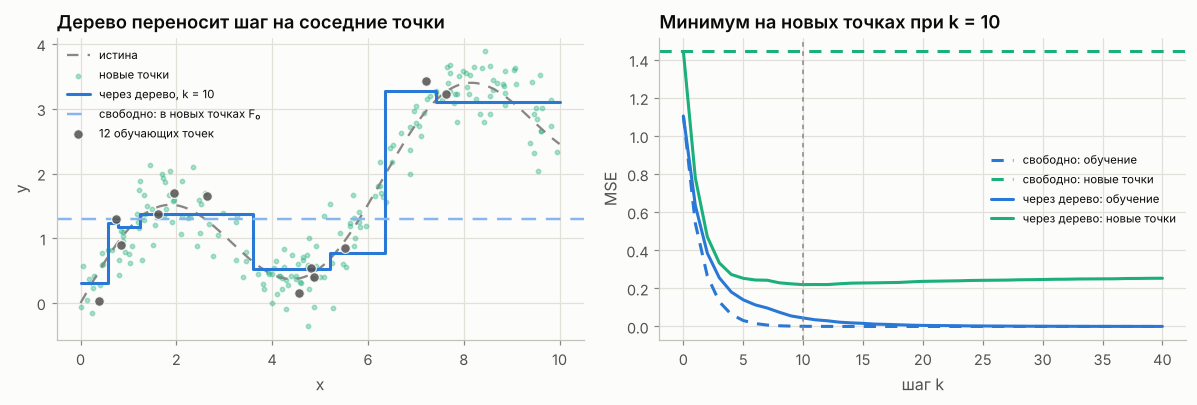

In [45]:
nu_table = {}
for nu_i, M_i in [(1, 10), (0.5, 15), (0.3, 25), (0.1, 80), (0.03, 250)]:
    g = GBRegressor(n_estimators=M_i, learning_rate=nu_i, max_depth=2).fit(Xw, yw)
    te = [mse(yt, g.predict(Xt, n_iter=k)) for k in range(M_i + 1)]
    m_best = int(np.argmin(te))
    nu_table[nu_i] = (m_best, te[m_best], te[2 * m_best])
    print(f"ν = {nu_i:<4}: лучшее M = {m_best:3d}, ν·M = {nu_i * m_best:.2f}, MSE {te[m_best]:.4f}; "
          f"при 2M деревьях {te[2 * m_best]:.4f}")
assert [v[0] for v in nu_table.values()] == [4, 6, 10, 35, 118]
assert [round(v[1], 4) for v in nu_table.values()] == [0.2439, 0.2215, 0.2196, 0.2168, 0.2161]
assert round(nu_table[1][2], 4) == 0.2606 and round(nu_table[0.03][2], 4) == 0.2353

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
plot_truth(axes[0], "wave", label="истина")
axes[0].scatter(Xt[:, 0], yt, s=8, color=ROLE["test"], alpha=0.35, label="новые точки")
grid_x = np.linspace(0, 10, 500).reshape(-1, 1)
axes[0].plot(grid_x[:, 0], gb.predict(grid_x, n_iter=10), color=ROLE["model"], drawstyle="steps-mid",
             label="через дерево, k = 10")
axes[0].axhline(yw.mean(), color=ROLE["model_prev"], ls=(0, (6, 4)), lw=1.6, label="свободно: в новых точках F₀")
plot_data(axes[0], Xw, yw, label="12 обучающих точек", s=40)
axes[0].set(xlabel="x", ylabel="y", title="Дерево переносит шаг на соседние точки")
axes[1].plot(free_tr, color=ROLE["train"], ls=(0, (4, 3)), label="свободно: обучение")
axes[1].axhline(free_te, color=ROLE["test"], ls=(0, (4, 3)), label="свободно: новые точки")
axes[1].plot(gb_tr, color=ROLE["train"], label="через дерево: обучение")
axes[1].plot(gb_te, color=ROLE["test"], label="через дерево: новые точки")
axes[1].axvline(k_best, color=style.MUTED, ls=(0, (3, 3)), lw=1)
axes[1].set(xlabel="шаг k", ylabel="MSE", title=f"Минимум на новых точках при k = {k_best}")
for ax in axes:
    ax.legend(fontsize=7.5)
fig.tight_layout()
plt.show()

### Шаг 15. Два алгоритма рядом

Градиентный бустинг — это градиентный спуск, в котором одна строка заменена: вместо шага по антиградиенту —
дерево, обученное на антиградиенте. Запишем оба алгоритма одинаково и запустим на шести квартирах
(½·Σ(y − F)², $\nu = 0.5$, три шага).

In [46]:
def gradient_descent_k(grad, theta0, eta, K):
    """Градиентный спуск: K шагов θ ← θ + η·(−∇f(θ))."""
    theta = np.array(theta0, float)
    for _ in range(K):
        g = grad(theta)
        step = -g  # ← шаг: сам антиградиент
        theta = theta + eta * step
    return theta


def gradient_boosting(xs, ys, neg_grad, nu, M):
    """Градиентный бустинг на пнях: та же схема, но шаг — дерево, обученное на антиградиенте."""
    F0 = ys.mean()  # старт: лучшая константа для ½·MSE
    F = np.full(len(ys), F0)
    trees = []
    for _ in range(M):
        r = neg_grad(ys, F)  # псевдо-остатки = антиградиент
        cands = (xs[:-1] + xs[1:]) / 2  # пороги — перебором
        t = min(cands, key=lambda t: np.sum((r - np.where(xs <= t, r[xs <= t].mean(), r[xs > t].mean())) ** 2))
        left, right = r[xs <= t].mean(), r[xs > t].mean()
        tree = lambda q, t=t, left=left, right=right: np.where(q <= t, left, right)  # ← шаг: дерево по (xᵢ, rᵢ)
        F = F + nu * tree(xs)
        trees.append(tree)
    return lambda q: F0 + nu * sum(tree(q) for tree in trees)


F_gd = gradient_descent_k(lambda F: F - y, np.full(6, 7.0), eta=0.5, K=3)  # ∇ ½Σ(y − F)² = F − y
model = gradient_boosting(x, y, lambda ys, F: ys - F, nu=0.5, M=3)
print("спуск по прогнозам, 3 шага: прогнозы", F_gd, "— квартира 65 м²: правила нет, остаётся 7")
print("бустинг, 3 пня:  прогнозы", model(x), "— квартира 65 м² →", model(np.array([65.0]))[0])
ref = GBRegressor(n_estimators=3, learning_rate=0.5, max_depth=1).fit(x.reshape(-1, 1), y)
print("gbcourse.GBRegressor(max_depth=1):", ref.predict(np.array([[80.0], [65.0]])))
assert np.isclose(F_gd[-1], 12.25) and np.allclose(model(np.array([80.0, 65.0])), [11.55, 7.65])
assert np.allclose(model(np.array([80.0, 65.0])), ref.predict(np.array([[80.0], [65.0]])))

спуск по прогнозам, 3 шага: прогнозы [ 3.5    5.25   4.375  7.875  8.75  12.25 ] — квартира 65 м²: правила нет, остаётся 7
бустинг, 3 пня:  прогнозы [ 4.65  4.65  4.65  7.65  8.85 11.55] — квартира 65 м² → 7.65
gbcourse.GBRegressor(max_depth=1): [11.55  7.65]


Строки соответствуют друг другу: старт — лучшая константа (шаг 4), градиент — псевдо-остатки (шаг 3), шаг — дерево
(шаг 14), темп — `learning_rate` (шаг 6), остановка — ранняя остановка (шаг 8). Это та же формула
$F_M = F_0 + \nu\sum_m h_m$, что в уроке 1.

> **Привал IV: мост построен.**
> - Если параметры — прогнозы, антиградиент — вектор псевдо-остатков, а свободный спуск лишь запоминает ответы.
> - Дерево приближает антиградиент функцией от $x$ и обобщает шаг на новые объекты; это направление спуска
>   ($h\cdot r > 0$).
> - Пороги ищут перебором — по ним рельеф ступенчатый; производные берут по прогнозам.

## Сверка с библиотеками

**1. Прямая для квартир: scikit-learn = МНК = спуск.** `LinearRegression` решает задачу формулой (метод
наименьших квадратов), спуск — шагами. По стандартизованному признаку спуск с $\eta = 1$ приходит в минимум за
один шаг (шаг 12); переводим ответ обратно к площадям.

In [47]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier

lin = LinearRegression().fit(x.reshape(-1, 1), y)
a_ls, b_ls = np.polyfit(x, y, 1)
z6 = (x - x.mean()) / x.std()
grad_line = lambda w: -np.array([np.mean((y - w[0] * z6 - w[1]) * z6), np.mean(y - w[0] * z6 - w[1])])
w = gradient_descent_k(grad_line, [0.0, 0.0], eta=1.0, K=1)
a_gd, b_gd = w[0] / x.std(), w[1] - w[0] * x.mean() / x.std()
print(f"scikit-learn:      a = {lin.coef_[0]:.6f}, b = {lin.intercept_:.6f}")
print(f"МНК (np.polyfit):  a = {a_ls:.6f}, b = {b_ls:.6f}")
print(f"спуск, 1 шаг по z: a = {a_gd:.6f}, b = {b_gd:.6f}")
assert np.allclose([lin.coef_[0], lin.intercept_], [a_gd, b_gd]) and np.allclose([a_ls, b_ls], [a_gd, b_gd])
assert np.allclose([a_gd, b_gd], [0.188571, -3.371429], atol=1e-6)

scikit-learn:      a = 0.188571, b = -3.371429
МНК (np.polyfit):  a = 0.188571, b = -3.371429
спуск, 1 шаг по z: a = 0.188571, b = -3.371429


**2. Лист XGBoost = шаг Ньютона $-G/(H + \lambda)$.** Десять клиентов из шага 9 и константный признак: дерево
не может разбить объекты, и все попадают в один лист. `base_score=0.5` — старт $p = 0.5$, то есть логит
$F_0 = 0$; `learning_rate=1` — без усадки; `min_child_weight=0` — лист разрешён при любом $H$. Маржа (логит после
одного дерева) должна равняться $-2/2.5 = -0.8$ при $\lambda = 0$ и $-2/3.5 \approx -0.5714$ при $\lambda = 1$.

In [48]:
Xk = np.zeros((10, 1))  # константный признак
for lam in (0, 1):
    xgb = XGBClassifier(n_estimators=1, learning_rate=1, base_score=0.5, max_depth=1, min_child_weight=0,
                        reg_lambda=lam)
    xgb.fit(Xk, yk)
    margin = float(xgb.predict(Xk, output_margin=True)[0])
    print(f"λ = {lam}: XGBoost — маржа {margin:+.4f}; по формуле −G/(H + λ) = {-G / (H + lam):+.4f}; "
          f"дерево: {xgb.get_booster().get_dump(with_stats=True)[0].strip()}")
    assert abs(margin - (-G / (H + lam))) < 1e-6

λ = 0: XGBoost — маржа -0.8000; по формуле −G/(H + λ) = -0.8000; дерево: 0:leaf=-0.800000012,cover=2.5
λ = 1: XGBoost — маржа -0.5714; по формуле −G/(H + λ) = -0.5714; дерево: 0:leaf=-0.571428597,cover=2.5


**3. Градиентный бустинг scikit-learn = `gbcourse.GBRegressor`.** 12 точек волны из шага 14, 20 деревьев глубины 2,
$\nu = 0.3$: прогнозы совпадают до последних знаков.

In [49]:
sk = GradientBoostingRegressor(n_estimators=20, learning_rate=0.3, max_depth=2).fit(Xw, yw)
ours = GBRegressor(n_estimators=20, learning_rate=0.3, max_depth=2).fit(Xw, yw)
diff_tr = np.max(np.abs(sk.predict(Xw) - ours.predict(Xw)))
diff_te = np.max(np.abs(sk.predict(Xt) - ours.predict(Xt)))
print(f"наибольшая разница прогнозов: на обучении {diff_tr:.1e}, на 200 новых точках {diff_te:.1e}")
print(f"MSE на новых точках: scikit-learn {mse(yt, sk.predict(Xt)):.4f}, gbcourse {mse(yt, ours.predict(Xt)):.4f}")
assert diff_tr < 1e-12 and diff_te < 1e-12

наибольшая разница прогнозов: на обучении 0.0e+00, на 200 новых точках 0.0e+00
MSE на новых точках: scikit-learn 0.2368, gbcourse 0.2368


**4. Листья MAE — медианы остатков.** Шаг 14: пень строят по знакам остатков, а значение листа пересчитывают
медианой обычных остатков. Квартиры, старт — медиана 6.5, один пень с темпом 1: прогнозы 4 и 9 и в scikit-learn,
и в LightGBM.

In [50]:
import lightgbm as lgb

sk_mae = GradientBoostingRegressor(loss="absolute_error", n_estimators=1, learning_rate=1, max_depth=1)
sk_mae.fit(x.reshape(-1, 1), y)
lgb_mae = lgb.LGBMRegressor(objective="l1", n_estimators=1, learning_rate=1, num_leaves=2, min_child_samples=1,
                            min_data_in_bin=1, verbose=-1).fit(x.reshape(-1, 1), y)
print("scikit-learn:", sk_mae.predict(x.reshape(-1, 1)))
print("LightGBM:    ", lgb_mae.predict(x.reshape(-1, 1)))
assert np.allclose(sk_mae.predict(x.reshape(-1, 1)), [4, 4, 4, 9, 9, 9])
assert np.allclose(lgb_mae.predict(x.reshape(-1, 1)), [4, 4, 4, 9, 9, 9])

scikit-learn: [4. 4. 4. 9. 9. 9.]
LightGBM:     [4. 4. 4. 9. 9. 9.]


**5. Подвох LightGBM: `subsample` без `subsample_freq` молча игнорируется** (шаг 13).

In [51]:
Xs, ys = datasets.regression_1d(kind="wave", n=300, noise=0.3, seed=5)
base = lgb.LGBMRegressor(n_estimators=20, verbose=-1).fit(Xs, ys).predict(Xs)
no_freq = lgb.LGBMRegressor(n_estimators=20, subsample=0.5, verbose=-1).fit(Xs, ys).predict(Xs)
with_freq = lgb.LGBMRegressor(n_estimators=20, subsample=0.5, subsample_freq=1, verbose=-1).fit(Xs, ys).predict(Xs)
print("subsample=0.5 без freq совпадает с subsample=1:", np.array_equal(base, no_freq))
print("subsample=0.5 и subsample_freq=1 совпадает:  ", np.array_equal(base, with_freq))
assert np.array_equal(base, no_freq) and not np.array_equal(base, with_freq)

subsample=0.5 без freq совпадает с subsample=1: True
subsample=0.5 и subsample_freq=1 совпадает:   False


## Итоги

1. Минимум ищут формулой (редко есть), перебором (проклятие размерности) или спуском — по наклону в текущей точке.
2. Производная — предел наклона секущей; $f(\theta + \Delta) \approx f + f'\Delta$. Производные потерь:
   $\partial_F \tfrac12 (y - F)^2 = -(y - F)$, $\partial_F |y - F| = -\operatorname{sign}(y - F)$, для log-loss —
   $p - y$; минус производная — псевдо-остаток.
3. Алгоритм: $\theta \leftarrow \theta - \eta f'(\theta)$, пока наклон не мал. Для константы под ½·MSE это бустинг
   одного числа.
4. Шаг работает, потому что $f(\theta - \eta f') \approx f - \eta (f')^2$; для параболы точно
   $f - \eta(1 - a\eta/2)(f')^2$.
5. Множитель $1 - \eta a$: сходимость при $0 < \eta < 2/a$, лучший темп $1/a$, сходимость линейная; шагов
   $\approx \ln(1/d)/(\eta a)$, в бустинге важна пара $\nu M$.
6. Плоское дно, изломы и ложные ямы мешают спуску; выпуклые потери ($f'' \ge 0$) гарантируют, что найденный
   минимум глобальный.
7. Темп подбирают сеткой, поиском с возвратом или затуханием; диагноз ставят по кривой потерь; в бустинге $\nu$
   мал, а число деревьев решает ранняя остановка.
8. Шаг Ньютона $-f'/f''$ берёт темп из кривизны; вблизи минимума с $f'' > 0$ сходится квадратично, вдали может
   разойтись. В суммах $-G/(H + \lambda)$ — значения листьев XGBoost; бустингу Ньютон ценен правильным масштабом
   шага, а не скоростью.
9. Градиент — вектор наклонов срезов, перпендикулярный линиям уровня; $-\nabla f$ — самый крутой спуск, а любое
   $u$ с $\nabla f\cdot u < 0$ — направление спуска.
10. Вытянутость $\kappa$ замедляет спуск: даже при лучшем темпе шагов около $(\kappa/2)\ln(1/d)$, то есть
    пропорционально $\kappa$. Лечат нормировкой признаков и инерцией. Деревьям масштаб безразличен.
11. Стохастический спуск шагает по мини-пакетам — дёшево и шумно; шум гасит затухающий темп
    ($\sum\eta_k = \infty$, $\sum\eta_k^2 < \infty$). В бустинге это `subsample`.
12. Если параметры — прогнозы, а шаг приближает дерево, получается градиентный бустинг: он обобщает на новые
    точки, а его шаг — направление спуска ($h \cdot r > 0$). Пороги перебирают, листья считают по производным.
    Маленький $\nu$ в бустинге не только замедляет, но и регуляризует.

## Упражнения

Нумерация совпадает со страницей урока и файлом упражнений; внутри части — от простого к сложному.

**Часть I. Производная**

1. **Секущая на квартирах ★☆☆.** Для $f(c)$ шести квартир посчитайте наклон секущей между $c = 10$ и
   $c = 10 + \varepsilon$ при $\varepsilon = 1$ и $0.1$. К чему он стремится? Сравните с формулой $f'(c) = c - 7$.
2. **Производная потерь Хьюбера ★★☆.** Найдите $\partial L/\partial F$ для $L = \tfrac12 (y - F)^2$ при
   $|y - F| \le \delta$ и $L = \delta(|y - F| - \tfrac12\delta)$ иначе. Проверьте центральной разностью при $y = 5$,
   $\delta = 1$ в точках $F = 4.5$ и $F = 2$.
3. **Производная сигмоиды ★★☆.** Выведите $\sigma'(F) = \sigma(F)(1 - \sigma(F))$ и проверьте центральной
   разностью в точке $F = 0.3$.
4. **Какое $\varepsilon$ лучше ★★☆.** Для $f(\theta) = \theta^3$ в точке 1 посчитайте ошибки разностей «вперёд»
   и центральной при $\varepsilon = 10^{-1}, 10^{-2}, \ldots, 10^{-12}$. При каком $\varepsilon$ каждая точнее
   всего и почему ошибка потом растёт?

**Часть II. Спуск по одной переменной**

5. **Три шага руками ★☆☆.** $f(\theta) = (\theta - 3)^2$, $\theta_0 = 0$, $\eta = 0.25$. Найдите
   $\theta_1, \theta_2, \theta_3$. Во сколько раз уменьшается расстояние до минимума за шаг?
6. **Граница расходимости ★☆☆.** Для $f(\theta) = 5\theta^2$ при каких $\eta$ спуск сходится? Какой $\eta$ даёт
   минимум за один шаг? Какие два темпа дают множитель по модулю 0.5?
7. **Обещание касательной ★★☆.** Для квартир, $c = 0$, проверьте формулу
   $f(c - \eta f') = f(c) - \eta(1 - a\eta/2)f'^2$ при $\eta = 0.1$ и $\eta = 2.5$. При каком $\eta$ выигрыш ровно
   вдвое меньше обещанного касательной?
8. **Спуск для медианы ★★☆.** Спуск по MAE для шести квартир с $\eta = 0.5$ из $c = 0$. Почему первые шаги ровно
   по 0.5? Почему седьмой шаг равен 0.417? Где спуск остановится и почему не дойдёт до медианы 6.5?
9. **Правило ν·M ★☆☆.** Сколько шагов «бустинга одного числа» нужно, чтобы остаток стал меньше 1 % исходного,
   при $\nu = 0.3$, $0.1$ и $0.01$? Почему $\nu M$ примерно постоянно?
10. **Ньютон для параболы ★★☆.** Покажите, что для любой параболы $f(\theta) = \tfrac a2 (\theta - m)^2 + c$
    с $a > 0$ шаг Ньютона из любой точки попадает ровно в минимум $m$.
11. **Лист XGBoost ★★☆.** В лист попали 4 клиента с $y = (1, 0, 0, 0)$, текущий логит у всех $F = 0$. Найдите
    $G$, $H$, шаг Ньютона $-G/H$ и лист XGBoost $-G/(H + \lambda)$ при $\lambda = 1$. Какая вероятность получится
    после шага Ньютона?

**Часть III. Много параметров**

12. **Градиент руками ★☆☆.** Две точки $(x, y)$: $(1, 2)$ и $(2, 3)$, прямая $ax + b$,
    $f(a, b) = \tfrac12\cdot\text{MSE}$. Найдите $\nabla f(0, 0)$ и точку после шага с $\eta = 0.1$.
13. **Вытянутая чаша ★★☆.** $f = \tfrac12(\theta_1^2 + 50\,\theta_2^2)$. Какой наибольший постоянный темп ещё
    сходится? Каковы множители по $\theta_1$ и $\theta_2$ при лучшем постоянном темпе $2/(1 + \kappa)$ и сколько
    шагов нужно до точности 0.1 % из $(2.5, 1)$? Что изменится, если заменить $\theta_2 = u/\sqrt{50}$?
14. **Затухающий темп в SGD ★★☆.** Покажите, что стохастический спуск для константы
    $c \leftarrow c + \eta_k(y_{i_k} - c)$ с $c_0 = 0$ и $\eta_k = 1/(k + 1)$ после $k$ шагов даёт ровно среднее
    выбранных цен.

**Часть IV. Мост к бустингу**

15. **Рельеф по порогу ★★☆.** Для шести квартир посчитайте сумму квадратов остатков после пня ($\nu = 1$) для
    порогов в каждом интервале $[30, 40), \ldots, [70, 80)$. Почему спуск по порогу невозможен и как выбирают
    порог?
16. **Шаг-дерево — направление спуска ★★★.** Для шести квартир возьмите пень с порогом 75 вместо 55. Посчитайте
    $h\cdot r$ и сумму квадратов после шага с $\nu = 0.5$. Это всё ещё спуск? Почему пень с порогом 55 лучше?
17. **Почему бустингу нужны деревья ★★★.** В виджете шага 14 (или в коде выше) сделайте 40 шагов «свободным»
    спуском и бустингом. Объясните, почему обучающая ошибка свободного спуска ниже, а на новых точках — наоборот.

<details><summary>Решения</summary>

`python lessons/lesson_1_3/exercises/solutions.py`
</details>